ChargeAgent: An Autonomous Multi-Agent AI Framework for Regional EV Demand Forecasting and Charging Infrastructure Planning Using India EV Market Data

In [1]:

#To download  datasets from Kaggle, install  KaggleHub package.Install  KaggleHub package to download  datasets from  kaggle website.
import kagglehub
#Store  downloaded dataset path in  variable path.Set variable path equal to  location of downloaded dataset.
#Objective: Ensure that  Kaggle dataset has been downloaded correctly.Commit Objective 04: Ensure that Kaggle dataset has been successfully downloaded.
path = kagglehub.dataset_download("mafzal19/electric-vehicle-sales-by-state-in-india")

100%|██████████| 453k/453k [00:00<00:00, 556kB/s]

Extracting files...


In [2]:

#Install CatBoost library for the development of the machine learning model.
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [23]:
# Importing necessarry packages and setting up the environment
import warnings
# Suppress all warning messages during runtime
warnings.filterwarnings('ignore')
# Importoperating system related utilities for file management
# Importings time utilities for execution time calculation
#load JSON library for reading and writing JSON files
# Importing Pickles for save and load trained models
import os, time, json, pickle
# install NumPy for numerical computations and matrix operations
import numpy as nps
# Importing Pandas for data loading, preprocessing, and analysis
import pandas as pdx
# lauch Matplotlib for data visualization and plotting
import matplotlib.pyplot as pltx
# install ticker utilities for customizing plot axes
import matplotlib.ticker as mticker
# Importing Seaborn for statistical data visualization
import seaborn as sns
# Importing StandardScaler for feature standardization
# import LabelEncoder for encoding categorical variables
from sklearn.preprocessing import StandardScaler, LabelEncoder

#  VarianceThreshold for removing low-variance features
#  Mutual Information for feature relevance analysis
# Importing Recursive Feature Elimination (RFE) for feature selection
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE

# launced Random Forest Regressor for ensemble-based prediction
# ImportingExtra Trees Regressor for feature importance estimation
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# Importing TimeSeriesSplit for leakage-free timeseries crossvalidation
#  RandomizedSearchCV for hyperparameteroptimization
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
# Importing regression evaluation metrics:
# Mean Squared Error (MSE)
# Mean Absolute Error (MAE)
# R² Score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# theLightGBM regression model
import lightgbm as lgb
#  theXGBoost regression model
import xgboost as xgb
# Importing the CatBoost regression model
from catboost import CatBoostRegressor
# Setting a  random seed to ensure reproducible experimentals results
RANDOM_STATE = 42
# Initializing NumPy random number generator with the fixed seed
nps.random.seed(RANDOM_STATE)
# Defining the path to the Electric Vehicle dataset stored in the Kaggle iut directory
DATA_PATH = "/kaggle/input/datasets/mafzal19/electric-vehicle-sales-by-state-in-india/EV_Dataset.csv"
# Defining the directory for saving trained models, scalers, encoders, and other artifacts
MODEL_DIR = "/kaggle/working/models"
# Creating the model directory if it does not already exist
os.makedirs(MODEL_DIR, exist_ok=True)
# Displaying a confirmation message indicating successful environment setup
print("Setup complete.")

Setup complete.


In [4]:


# Configuring a global plotting style for consistent visualization


# Updating  global Matplotlib configuration for all generated plots
pltx.rcParams.update({

    # Setting  default font weight to bold for all text
    'font.weight': 'bold',

    # Setting plot titles to bold
    'axes.titleweight': 'bold',

    # Setting Xaxis and Yaxis labels to bold
    'axes.labelweight': 'bold',

    # Set  default font size for plot titles
    'axes.titlesize': 15,

    # Settinng  default font size for axis labels
    'axes.labelsize': 13,

    # Setting  default font size for Xaxis tick labels
    'xtick.labelsize': 11,

    # Setting  default font size for Yaxis tick labels
    'ytick.labelsize': 11,

    # Setting  figure background color to white
    'figure.facecolor': 'white',

    # Setting  axes background color to white
    'axes.facecolor': 'white',

    # Setting  axes border color to black
    'axes.edgecolor': 'black',

    # Setting  thickness of  axes border
    'axes.linewidth': 1.2,

    # Setting  transparency level of grid lines
    'grid.alpha': 0.3,

    # Setting  default font size for plot legends
    'legend.fontsize': 11,
})

# Defining a reusable function to apply bold formatting to plot elements
def bold_axes(ax):

    # Applying bold formatting to all Xaxis and Yaxis tick labels

    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')

    # Applyingbold formatting to  plot title
    ax.title.set_fontweight('bold')

    # Applying bold formatting to  Xaxis label
    ax.xaxis.label.set_fontweight('bold')

    # Applying bold formatting to  Yaxis label
    ax.yaxis.label.set_fontweight('bold')

    # Increasing  thickness of all plot borders (spines)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    # Returning the formatted axes object
    return ax

Step 1 — Data Acquisition Agent

In [5]:

# Loading  raw Electric Vehicle dataset from  specified file path
df_raw = pdx.read_csv(os.path.join(path, 'EV_Dataset.csv'))

# Displaying  number of rows and columns in  dataset
print("Shape:", df_raw.shape)

# Displaying  first 10 records of  dataset for initial inspection
df_raw.head(10)

Shape: (96845, 8)


,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0
5,2014.0,jan,1/1/2014,Andhra Pradesh,CASH VAN,Others,Others,0.0
6,2014.0,jan,1/1/2014,Andhra Pradesh,CRANE MOUNTED VEHICLE,Others,Others,0.0
7,2014.0,jan,1/1/2014,Andhra Pradesh,EDUCATIONAL INSTITUTION BUS,Bus,Institution Bus,0.0
8,2014.0,jan,1/1/2014,Andhra Pradesh,EXCAVATOR (COMMERCIAL),Others,Others,0.0
9,2014.0,jan,1/1/2014,Andhra Pradesh,FORK LIFT,Others,Others,0.0


## Step 2 — Data Validation Agent Schema, missing values, duplicates, date consistency, invalid categories, numeric ranges before any preprocessing.

In [7]:


# Making a copy of  dataset to perform preprocessing steps


# Creating a copy of  original dataset to preserve  raw data
df = df_raw.copy()

# Displaying  schema and data types of all columns
print(" SCHEMA ")
print(df.dtypes)

# Displaying  number of missing values in each column
print("\n MISSING VALUES ")
print(df.isnull().sum())

# Checking for duplicate records in  dataset
print("\n DUPLICATE ROWS ")

# Displaying  total number of exact duplicate rows
print("Exact duplicate rows:", df.duplicated().sum())

# Validating  Date column for consistency
print("\n DATE CONSISTENCY ")

# Converting  Date column into datetime format using  specified date pattern
df['Date'] = pdx.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

# Displaying  number of invalid or unparseable date values
print("Unparseable dates:", df['Date'].isna().sum())

# Displaying  minimum and maximum dates available in  dataset
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# Checking wher  Month_Name column matches  month extracted from  Date column
print("Month_Name vs parsed month mismatch:",
      (df['Date'].dt.strftime('%b').str.lower() != df['Month_Name'].str.lower()).sum())

# Validating  categorical feature values
print("\n CATEGORY VALIDITY ")

# Displaying  number of unique values in each categorical column
for c in ['State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type']:
    print(f"{c}: {df[c].nunique()} unique values")

# Performing statistical analysis of  target variable
print("\n NUMERIC RANGE CHECK ")

# Displaying descriptive statistics of  EV_Sales_Quantity column
print(df['EV_Sales_Quantity'].describe())

# Checking for invalid negative values in  EV_Sales_Quantity column
print("Negative sales values:", (df['EV_Sales_Quantity'] < 0).sum())

# Displaying a confirmation message after successful dataset validation
print("\n Dataset validated. Proceeding with", df.shape[0], "records.")

 SCHEMA 
Year                 float64
Month_Name            object
Date                  object
State                 object
Vehicle_Class         object
Vehicle_Category      object
Vehicle_Type          object
EV_Sales_Quantity    float64
dtype: object

 MISSING VALUES 
Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

 DUPLICATE ROWS 
Exact duplicate rows: 0

 DATE CONSISTENCY 
Unparseable dates: 0
Date range: 2014-01-01 00:00:00 to 2024-01-01 00:00:00
Month_Name vs parsed month mismatch: 0

 CATEGORY VALIDITY 
State: 34 unique values
Vehicle_Class: 73 unique values
Vehicle_Category: 5 unique values
Vehicle_Type: 12 unique values

 NUMERIC RANGE CHECK 
count    96845.000000
mean        37.108896
std        431.566675
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      20584.000000
Name: EV_Sal

## Step 3 — Exploratory Data Analysis (EDA Agent)
Descriptive statistics and visualization only — nothing here is fit to data or used to derive model parameters,

In [8]:

# Showing basic information of the Electric Vehicle dataset

# Displaying the total number of rows and columns in the dataset
print("Shape:", df.shape)

# Displaying the total number of unique states in the dataset
print("\nUnique States:", df['State'].nunique())

## Listing the number of unique vehicleclasses
print("Unique Vehicle Classes:", df['Vehicle_Class'].nunique())

# Displaying the total number of unique vehicle categories along with their category names
print("Unique Vehicle Categories:", df['Vehicle_Category'].nunique(),
      "-", list(df['Vehicle_Category'].unique()))

# Displaying the total number of unique vehicle types
print("Unique Vehicle Types:", df['Vehicle_Type'].nunique())

Shape: (96845, 8)

Unique States: 34
Unique Vehicle Classes: 73
Unique Vehicle Categories: 5 - ['Others', 'Bus', '2-Wheelers', '4-Wheelers', '3-Wheelers']
Unique Vehicle Types: 12


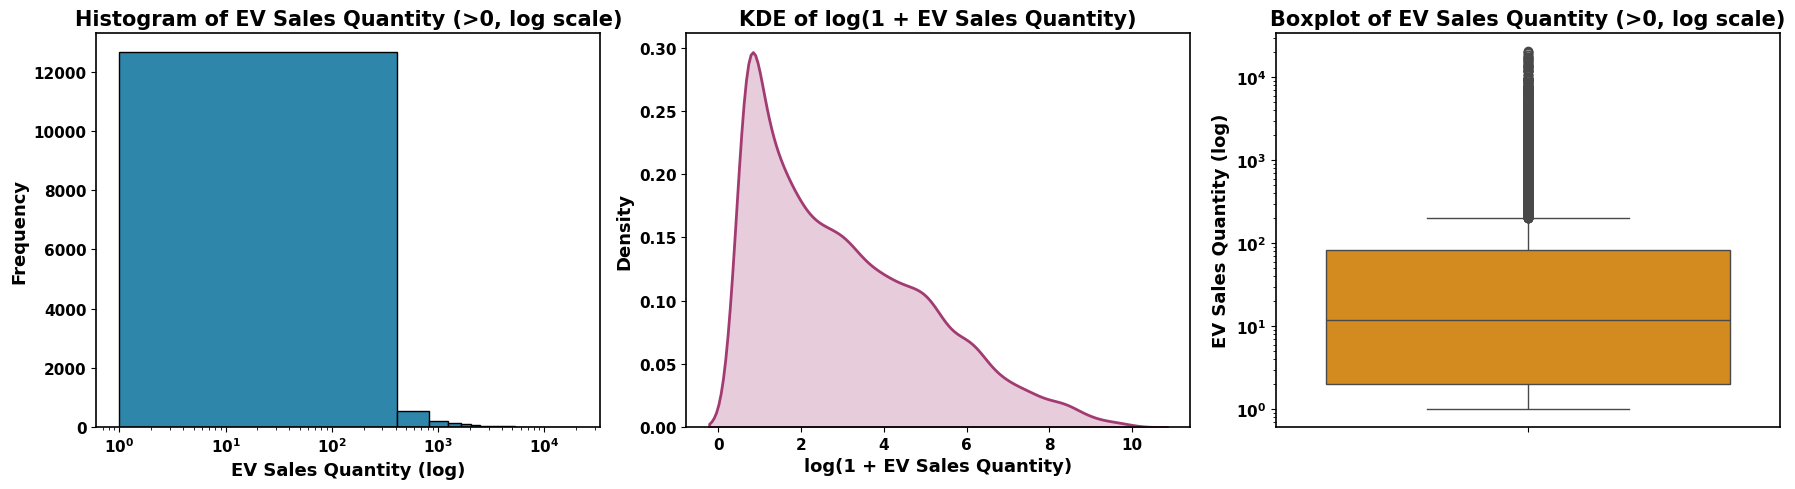

In [9]:


# Univariate analysis of EV Sales Quantity


# Creating a fig with three subplot for distribution analysis
fig, axes = pltx.subplots(1, 3, figsize=(18, 5))

# Selecting only positive EV sales values for logarithmic scale analysis
nz = df.loc[df['EV_Sales_Quantity'] > 0, 'EV_Sales_Quantity']

# Plotting  histogram of positive EV sales values
axes[0].hist(nz, bins=50, color='#2E86AB', edgecolor='black')

# Applying logarithmic scaling to  X-axis
axes[0].set_xscale('log')

# Setting  title of  histogram
axes[0].set_title('Histogram of EV Sales Quantity (>0, log scale)')

# Setting  X-axis label of  histogram
axes[0].set_xlabel('EV Sales Quantity (log)')

# Setting  Y-axis label of  histogram
axes[0].set_ylabel('Frequency')

# Applying  predefined bold formatting to  histogram
bold_axes(axes[0])

# Plotting  Kernel Density Estimation (KDE) of  log-transformed EV sales values
sns.kdeplot(nps.log1p(nz), ax=axes[1], color='#A23B72', fill=True, linewidth=2)

# Setting  title of  KDE plot
axes[1].set_title('KDE of log(1 + EV Sales Quantity)')

# Setting  X-axis label of  KDE plot
axes[1].set_xlabel('log(1 + EV Sales Quantity)')

# Setting  Yaxis label of  KDE plot
axes[1].set_ylabel('Density')

# Applying  predefined bold formatting to  KDE plot
bold_axes(axes[1])

# Plotting  boxplot of positive EV sales values
sns.boxplot(y=nz, ax=axes[2], color='#F18F01')

# Applying logarithmic scaling to  Y-axis
axes[2].set_yscale('log')

# Setting  titles of  boxplot
axes[2].set_title('Boxplot of EV Sales Quantity (>0, log scale)')

# Setting  Y-axis label of  boxplot
axes[2].set_ylabel('EV Sales Quantity (log)')

# Applying  predefined bold formatting to  boxplot
bold_axes(axes[2])

# Adjusting  spacing between subplots for better visualization
pltx.tight_layout()

# Displaying  generated plots
pltx.show()

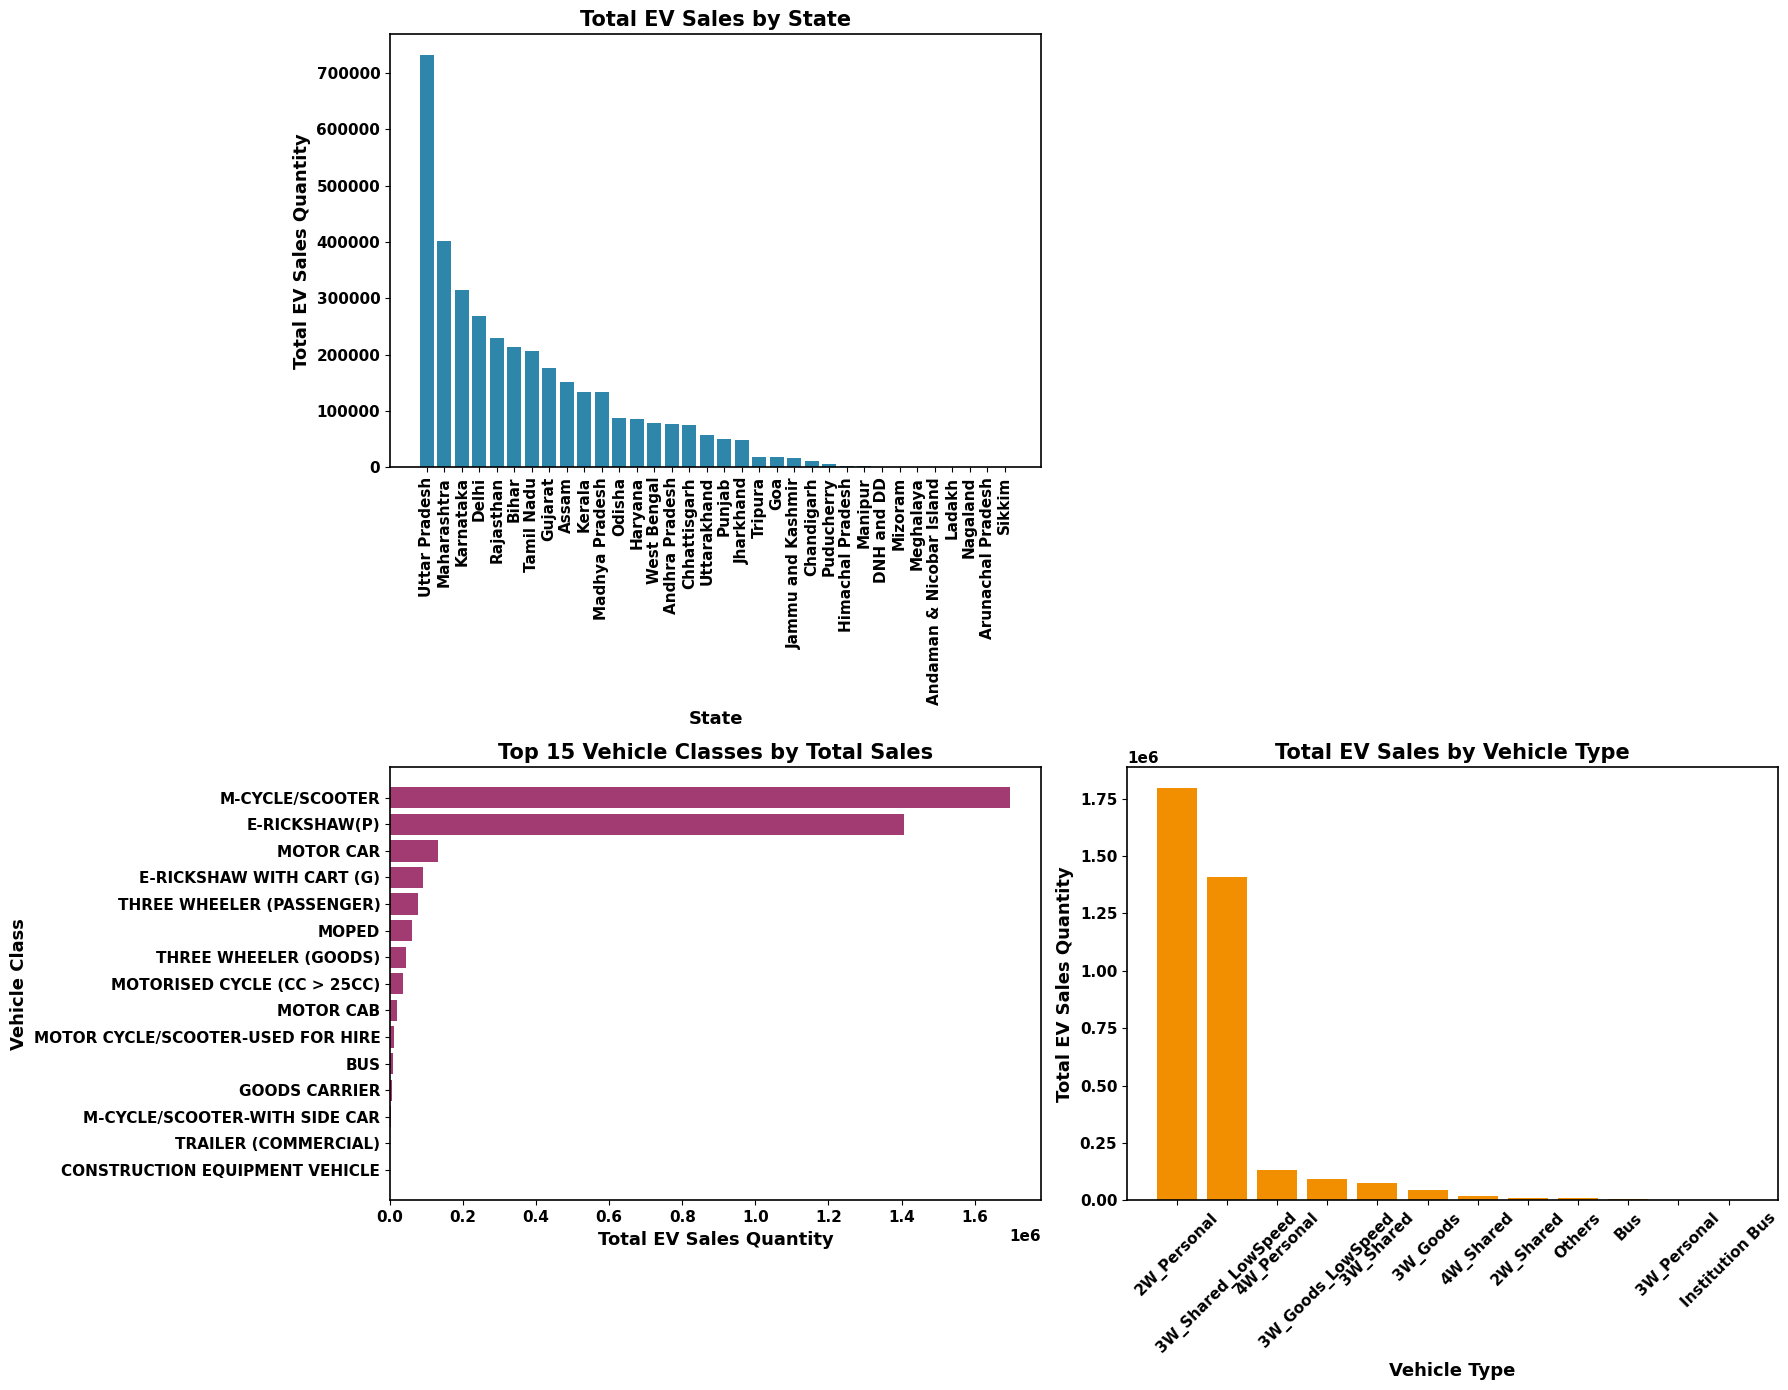

In [53]:

# Categorical Analysis of Electric Vehicle Sales


# Creating a figure with four subplots for categorical analysis
fig, axes = pltx.subplots(2, 2, figsize=(18, 14))

# Calculating  total EV sales for each state and sorting them in descending order
state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False)

# Plotting  total EV sales by state using a barchart
axes[0,0].bar(state_sales.index, state_sales.values, color='#2E86AB')

# Setting  title of  state-wise EV sales plot
axes[0,0].set_title('Total EV Sales by State')

# Setting  Xaxis label of  state-wise EV sales plot
axes[0,0].set_xlabel('State')

# Setting  Yaxis label of  state-wise EV sales plot
axes[0,0].set_ylabel('Total EV Sales Quantity')

# Rotating  state names on  Xaxis for better readability
axes[0,0].tick_params(axis='x', rotation=90)

# Applying  predefined bold formatting to  state-wise EV sales plot
bold_axes(axes[0,0])

# Removing  unused subplot slot (pie chart removed)
fig.delaxes(axes[0,1])

# Calculating  total EV sales for each vehicle class and selecting  top 15 classes
class_sales = df.groupby('Vehicle_Class')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(15)

# Plotting  top 15 vehicle classes using a horizontal bar chart
axes[1,0].barh(class_sales.index[::-1], class_sales.values[::-1], color='#A23B72')

# Setting  title of  top 15 vehicle class sales plot
axes[1,0].set_title('Top 15 Vehicle Classes by Total Sales')

# Setting  X-axis label of  vehicle class sales plot
axes[1,0].set_xlabel('Total EV Sales Quantity')

# Setting  Y-axis label of  vehicle class sales plot
axes[1,0].set_ylabel('Vehicle Class')

# Applying  predefined bold formatting to  vehicle class sales plot
bold_axes(axes[1,0])

# Calculating  total EV sales for each vehicle type and sorting them in descending order
type_sales = df.groupby('Vehicle_Type')['EV_Sales_Quantity'].sum().sort_values(ascending=False)

# Plotting  total EV sales by vehicle type using a barchart
axes[1,1].bar(type_sales.index, type_sales.values, color='#F18F01')

# Setting  title of  vehicle type sales plot
axes[1,1].set_title('Total EV Sales by Vehicle Type')

# Setting  X-axis label of  vehicle type sales plot
axes[1,1].set_xlabel('Vehicle Type')

# Setting  Y-axis label of  vehicle type sales plot
axes[1,1].set_ylabel('Total EV Sales Quantity')

# Rotating  vehicle type names on  X-axis for better readability
axes[1,1].tick_params(axis='x', rotation=45)

# Applying  predefined bold formatting to  vehicle type sales plot
bold_axes(axes[1,1])

# Adjusting  spacing between all subplots for better visualization
pltx.tight_layout()

# Displaying all categorical analysis plots
pltx.show()

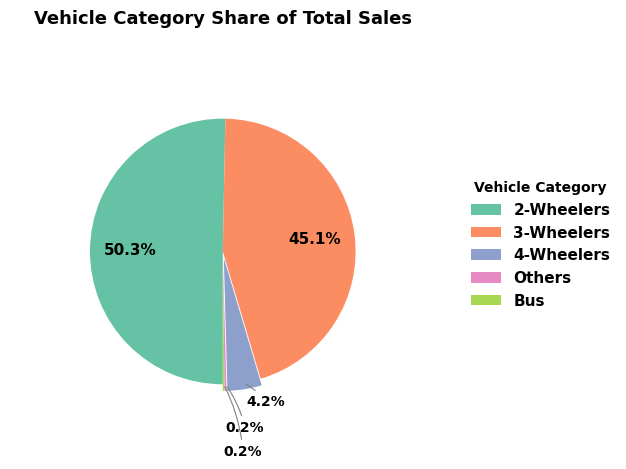

In [11]:


# Vehicle Category Pie Chart


# Calculating  total EV sales for each vehicle category and sorting them in descending order
cat_sales = df.groupby('Vehicle_Category')['EV_Sales_Quantity'].sum().sort_values(ascending=False)
total = cat_sales.sum()
pct_values = cat_sales.values / total * 100

# Exploding  smallest slices slightly so their wedges are visually separated
explode = [0.05 if p < 5 else 0 for p in pct_values]



# bottom-right instead, completely avoiding  title area
wedges, _ = pltx.gca().pie(
    cat_sales.values,
    labels=None,
    explode=explode,
    startangle=270,
    counterclock=False,
    textprops={'fontweight': 'bold', 'fontsize': 11},
    colors=sns.color_palette('Set2', len(cat_sales))
)

# Manually placing percentage labels:
small_slice_offset = 1.15   # base radius for outside labels
small_label_gap = 0.18      # vertical gap between stacked outside labels
small_idx = 0                # counter to stagger stacked small labels
#  Calculation of position for percentage labels within pie chart by wedge angle
#  Presentation of bold labels for large wedges inside  pie chart
#  Presentation of small wedges with percentage labels placed outside
#  Stacking of labels of small wedges to avoid overlapping
#  Placement of arrows connecting small wedges and their labels
#  Styling of all percentage labels in bold
for i, (wedge, pct) in enumerate(zip(wedges, pct_values)):
    ang = nps.deg2rad((wedge.theta1 + wedge.theta2) / 2)
    x, y = nps.cos(ang), nps.sin(ang)

    if pct >= 5:
        # Bold percentage text centered inside  wedge
        pltx.text(
            x * 0.7, y * 0.7, f'{pct:.1f}%',
            ha='center', va='center',
            fontweight='bold', fontsize=11
        )
    else:
        # Push small-slice labels further out and stagger them vertically
        label_x = x * small_slice_offset
        label_y = y * small_slice_offset - (small_idx * small_label_gap)
        small_idx += 1

        pltx.annotate(
            f'{pct:.1f}%',
            xy=(x * 1.0, y * 1.0),
            xytext=(label_x, label_y),
            ha='left' if x >= 0 else 'right',
            va='center',
            fontweight='bold', fontsize=10,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.8,
                             connectionstyle='arc3,rad=0.1')
        )

# Adding a legend outside  pie
pltx.legend(
    wedges,
    cat_sales.index,
    title='Vehicle Category',
    title_fontproperties={'weight': 'bold'},
    prop={'weight': 'bold'},
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

# Setting  title with extra top padding so it never touches any label/arrow
pltx.title('Vehicle Category Share of Total Sales', fontweight='bold', fontsize=13, pad=30)

# Keeping  pie a true circle
pltx.axis('equal')

# Giving extra headroom above  pie so exploded/rotated small slices have room
pltx.ylim(-1.3, 1.4)

# Adjusting  spacing for better visualization
pltx.tight_layout()

# Displaying  pie chart
pltx.show()

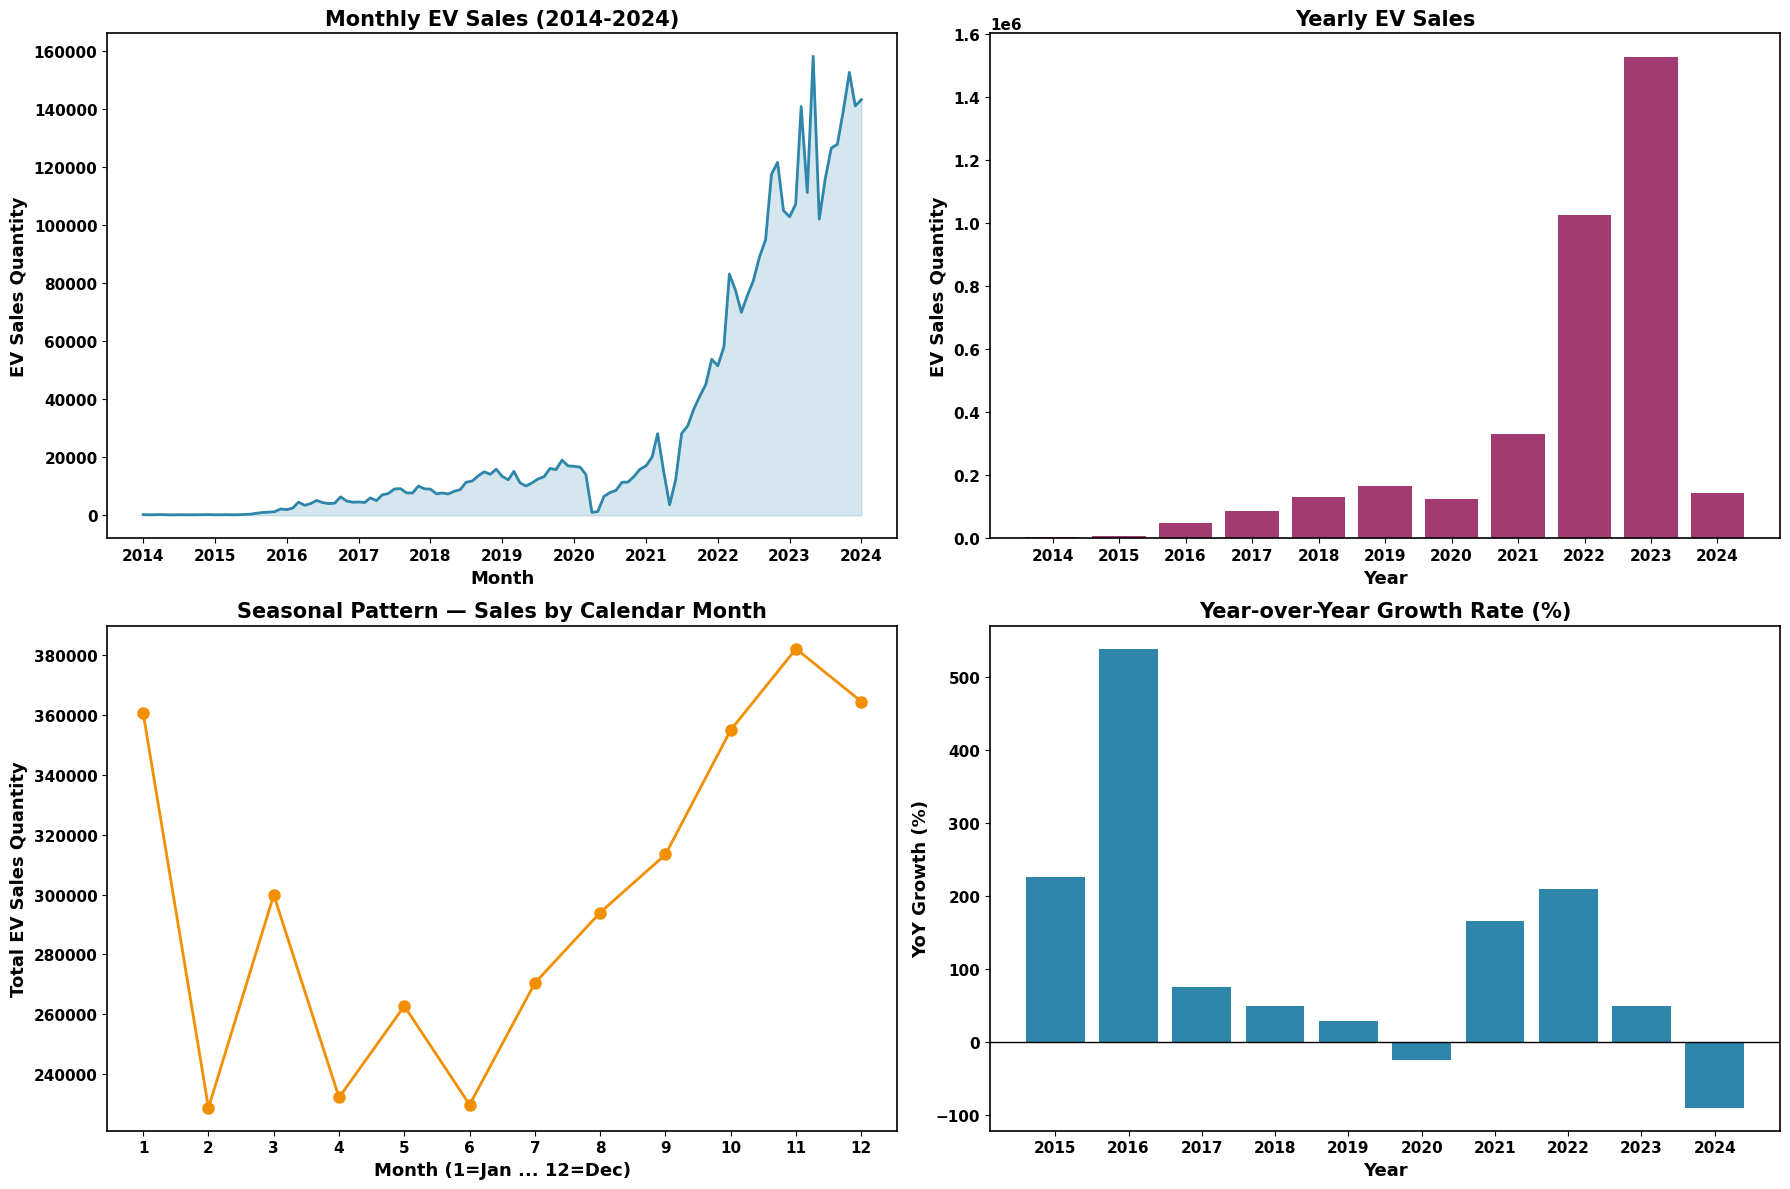

In [12]:


# Time Series Analysis of Electric Vehicle Sales


# Calculating  total monthly EV sales by aggregating records based on month
monthly = df.groupby(df['Date'].dt.to_period('M'))['EV_Sales_Quantity'].sum()

# Converting  monthly period index into timestamp format for plotting
monthly.index = monthly.index.to_timestamp()

# Calculating  total yearly EV sales
yearly = df.groupby('Year')['EV_Sales_Quantity'].sum()

# Calculating  total EV sales for each calendar month to analyze seasonal patterns
seasonal = df.groupby(df['Date'].dt.month)['EV_Sales_Quantity'].sum()

# Creating a figure with four subplots for time-series analysis
fig, axes = pltx.subplots(2, 2, figsize=(18, 12))

# Plotting  monthly EV sales trend using a line chart
axes[0,0].plot(monthly.index, monthly.values, color='#2E86AB', linewidth=2)

# Filling  area under  monthly sales curve for better visualization
axes[0,0].fill_between(monthly.index, monthly.values, alpha=0.2, color='#2E86AB')

# Setting  title of  monthly EV sales plot
axes[0,0].set_title('Monthly EV Sales (2014-2024)')

# Setting  Xaxis label of  monthly EV sales plot
axes[0,0].set_xlabel('Month')

# Setting  Yaxis label of  monthly EV sales plot
axes[0,0].set_ylabel('EV Sales Quantity')

# Applying  predefined bold formatting to  monthly EV sales plot
bold_axes(axes[0,0])

# Plotting  yearly EV sales using a bar chart
axes[0,1].bar(yearly.index.astype(int).astype(str), yearly.values, color='#A23B72')

# Setting  title of  yearly EV sales plot
axes[0,1].set_title('Yearly EV Sales')

# Setting  Xaaxis label of  yearly EV sales plot
axes[0,1].set_xlabel('Year')

# Setting  Yaxis label of  yearly EV sales plot
axes[0,1].set_ylabel('EV Sales Quantity')

# Applying  predefined bold formatting to  yearly EV sales plot
bold_axes(axes[0,1])

# Plotting  seasonal EV sales pattern across calendar months using a line chart
axes[1,0].plot(seasonal.index, seasonal.values, marker='o', color='#F18F01', linewidth=2, markersize=8)

# Setting  title of  seasonal sales pattern plot
axes[1,0].set_title('Seasonal Pattern — Sales by Calendar Month')

# Setting  X-axis label of  seasonal sales pattern plot
axes[1,0].set_xlabel('Month (1=Jan ... 12=Dec)')

# Setting  Y-axis label of  seasonal sales pattern plot
axes[1,0].set_ylabel('Total EV Sales Quantity')

# Displaying all twelve calendar months on  X-axis
axes[1,0].set_xticks(range(1,13))

# Applying  predefined bold formatting to  seasonal sales pattern plot
bold_axes(axes[1,0])

# Calculating  Year-over-Year (YoY) growth rate in percentage
yoy_growth = yearly.pct_change() * 100

# Plotting  Year-over-Year growth rate using a bar chart
axes[1,1].bar(yoy_growth.index.astype(int).astype(str)[1:], yoy_growth.values[1:], color='#2E86AB')

# Adding a horizontal reference line at zero growth
axes[1,1].axhline(0, color='black', linewidth=1)

# Setting  title of  Year-over-Year growth rate plot
axes[1,1].set_title('Year-over-Year Growth Rate (%)')

# Setting  X-axis label of  Year-over-Year growth rate plot
axes[1,1].set_xlabel('Year')

# Setting  Y-axis label of  Year-over-Year growth rate plot
axes[1,1].set_ylabel('YoY Growth (%)')

# Applying  predefined bold formatting to  Year-over-Year growth rate plot
bold_axes(axes[1,1])

# Adjusting  spacing between all subplots for better visualization
pltx.tight_layout()

# Displaying all time-series analysis plots
pltx.show()

In [13]:


# Outlier Analysis of EV Sales Quantity

# Selecting only positive EV sales values for outlier analysis
nz = df.loc[df['EV_Sales_Quantity'] > 0, 'EV_Sales_Quantity']

# Calculating  first quartile (Q1) and third quartile (Q3)
Q1, Q3 = nz.quantile(0.25), nz.quantile(0.75)

# Computing  Interquartile Range (IQR)
IQR = Q3 - Q1

# Identifying and counting outliers using  IQR method
iqr_outliers = ((nz < Q1 - 1.5 * IQR) | (nz > Q3 + 1.5 * IQR)).sum()

# Calculating  Zscore for each positive EV sales value
z_scores = (nz - nz.mean()) / nz.std()

# Identifying and counting outliers using  Z-score method (|Z| > 3)
z_outliers = (z_scores.abs() > 3).sum()

# Displaying  total number and percentage of IQR-based outliers
print(f"IQR-based outliers (of {len(nz)} nonzero records): {iqr_outliers} ({iqr_outliers/len(nz)*100:.2f}%)")

# Displaying  total number and percentage of Z-score-based outliers
print(f"Z-score based outliers (|z|>3): {z_outliers} ({z_outliers/len(nz)*100:.2f}%)")

# Displaying an explanation that  detected outliers represent genuine high-demand observations
print("\nThese are genuine high-demand state/month combinations (e.g. Maharashtra, Uttar Pradesh")

# Indicating that these outliers are retained because they correspond to real high-sales periods rather than data errors
print("in festive months), not data errors — NOT removed. Tree-based models used downstream")

# Explaining that no outlier removal is performed before the train-test split to prevent data leakage because tree-based models are naturally robust to such extreme values
print("are robust to them regardless.")

IQR-based outliers (of 14062 nonzero records): 2138 (15.20%)
Z-score based outliers (|z|>3): 237 (1.69%)

These are genuine high-demand state/month combinations (e.g. Maharashtra, Uttar Pradesh
in festive months), not data errors — NOT removed. Tree-based models used downstream
are robust to them regardless.


## Step 4 — Time-Series Train / Test Split (Leakage Prevention)
Sort by date, split chronologically, no shuffling. Future observations never enter training.
**Train: 2015-2022 Test: 2023 | Jan-2024: live-forecast seed only** .

In [15]:

# Setting leakage-free temporal data split boundaries


# Defining  end date of  training dataset
TRAIN_END = '2022-12-01'

# Defining  start and end dates of  testing dataset
TEST_START, TEST_END = '2023-01-01', '2023-12-01'

# Defining  latest available date for future forecasting (Live dataset)
LIVE_DATE = '2024-01-01'

# Displaying a confirmation message that temporal split boundaries are fixed before feature engineering to prevent data leakage
print("Split boundaries fixed BEFORE any feature is computed on  panel below.")

# Displaying  training data date range
print("Train  :", '2014-01-01', '-', TRAIN_END)

# Displaying  testing data date range
print("Test   :", TEST_START, '-', TEST_END)

# Displaying  live forecasting date used only for future prediction
print("Live   :", LIVE_DATE, "(latest real month, used only for future forecasting  )")

Split boundaries fixed BEFORE any feature is computed on the panel below.
Train  : 2014-01-01 - 2022-12-01
Test   : 2023-01-01 - 2023-12-01
Live   : 2024-01-01 (latest real month, used only for future forecasting  )


## Step 5 — Data Preprocessing Agent

In [16]:


# Building  complete State-Vehicle Category-Time Panel Dataset


# Aggregating EV sales quantity for each State, Vehicle Category, and Date combination
panel = df.groupby(['State', 'Vehicle_Category', 'Date'], as_index=False)['EV_Sales_Quantity'].sum()

# Extracting  sorted list of unique States
states_list = sorted(df['State'].unique())

# Extracting  sorted list of unique Vehicle Categories
cats_list = sorted(df['Vehicle_Category'].unique())

# Extracting  sorted list of unique Dates
dates_list = sorted(df['Date'].unique())

# Creating a complete panel grid containing every possible State, Vehicle Category, and Date combination
full_grid = pdx.MultiIndex.from_product(
    [states_list, cats_list, dates_list],
    names=['State', 'Vehicle_Category', 'Date']
)

# Reindexing  aggregated dataset using  complete panel grid
# Filling missing combinations with zero EV sales
# Resetting  index after reindexing
# Sorting  panel dataset by State, Vehicle Category, and Date
# Resetting  row index after sorting
panel = (
    panel.set_index(['State', 'Vehicle_Category', 'Date'])
         .reindex(full_grid, fill_value=0.0)
         .reset_index()
         .sort_values(['State', 'Vehicle_Category', 'Date'])
         .reset_index(drop=True)
)

# Displaying  dimensions of  completed panel dataset
print("Panel shape:", panel.shape, "=", len(states_list), "states x", len(cats_list), "categories x", len(dates_list), "months")

# Displaying  percentage of records with zero EV sales
print("Zero-sales rows:", (panel['EV_Sales_Quantity'] == 0).mean().round(3) * 100, "%")

# Displaying  first five records of  completed panel dataset
panel.head()

Panel shape: (20570, 4) = 34 states x 5 categories x 121 months
Zero-sales rows: 62.8 %


,State,Vehicle_Category,Date,EV_Sales_Quantity
0,Andaman & Nicobar Island,2-Wheelers,2014-01-01,0.0
1,Andaman & Nicobar Island,2-Wheelers,2014-02-01,0.0
2,Andaman & Nicobar Island,2-Wheelers,2014-03-01,0.0
3,Andaman & Nicobar Island,2-Wheelers,2014-04-01,0.0
4,Andaman & Nicobar Island,2-Wheelers,2014-05-01,0.0


## Step 6 — Feature Engineering Agent
All lag / rolling / growth features use only **past** values

In [17]:


# Feature Engineering for Time Series EV Demand Forecasting


# Extracting  month feature from  Date column
panel['Month'] = panel['Date'].dt.month

# Extracting  quarter feature from  Date column
panel['Quarter'] = panel['Date'].dt.quarter

# Extracting  year feature from  Date column
panel['Year'] = panel['Date'].dt.year

# Extracting  ISO week number from  Date column
panel['Week'] = panel['Date'].dt.isocalendar().week.astype(int)

# Creating cyclical month encoding using  sine transformation
panel['sin_month'] = nps.sin(2 * nps.pi * panel['Month'] / 12)

# Creating cyclical month encoding using  cosine transformation
panel['cos_month'] = nps.cos(2 * nps.pi * panel['Month'] / 12)

# Grouping  panel dataset by State and Vehicle Category for time-series feature generation
grp = panel.groupby(['State', 'Vehicle_Category'])['EV_Sales_Quantity']

# Creating lag features (1, 2, 3, 6, and 12 months) using only historical observations
for lag in [1, 2, 3, 6, 12]:
    panel[f'lag_{lag}'] = grp.shift(lag)

# Creating rolling mean features (3, 6, and 12 months) using shifted historical values to prevent data leakage
for w in [3, 6, 12]:
    panel[f'roll_mean_{w}'] = grp.transform(lambda s, w=w: s.shift(1).rolling(w).mean())

# Creating rolling standard deviation features (3 and 6 months) using shifted historical values
for w in [3, 6]:
    panel[f'roll_std_{w}'] = grp.transform(lambda s, w=w: s.shift(1).rolling(w).std())

# Calculating  month-over-month growth rate using historical lag values
panel['monthly_growth'] = (panel['lag_1'] - panel['lag_2']) / panel['lag_2'].replace(0, nps.nan)

# Calculating  year-over-year growth rate using historical lag values
panel['annual_growth'] = (panel['lag_1'] - panel['lag_12']) / panel['lag_12'].replace(0, nps.nan)

# Calculating  number of years elapsed for CAGR approximation
n_years = (
    (panel['Year'] -
     panel.groupby(['State', 'Vehicle_Category'])['Year'].transform('min'))
    .clip(lower=1)
)

# Calculating  approximate Compound Annual Growth Rate (CAGR)
panel['cagr_approx'] = (
    (panel['lag_1'] / panel['roll_mean_12'].replace(0, nps.nan))
    ** (1 / n_years)
) - 1

# Calculating  momentum feature as  difference between  previous month and three months earlier
panel['momentum'] = panel['lag_1'] - panel['lag_3']

# Placeholder for regional and segment demand context features (computed later using training data only)

# Creating numerical state identifiers for interaction feature generation
panel['state_code'] = panel['State'].astype('category').cat.codes

# Creating numerical vehicle category identifiers for interaction feature generation
panel['category_code'] = panel['Vehicle_Category'].astype('category').cat.codes

# Creating an interaction feature between state and month
panel['state_x_month'] = panel['state_code'] * panel['Month']

# Creating an interaction feature between vehicle category and month
panel['cat_x_month'] = panel['category_code'] * panel['Month']

# Creating charging demand index using previous demand relative to  historical rolling average
panel['charging_demand_index'] = (
    panel['lag_1'] / panel['roll_mean_12'].replace(0, nps.nan)
)

# Creating demand growth index using  annual growth feature
panel['demand_growth_index'] = panel['annual_growth']

# Displaying thetotal numberfeatures available in  panel dataset
print("Panel columns:", panel.shape[1])

# Displaying the last eight records of selected engineered features for verification
panel[['State', 'Vehicle_Category', 'Date',
       'EV_Sales_Quantity', 'lag_1',
       'roll_mean_12', 'annual_growth']].tail(8)

Panel columns: 30


,State,Vehicle_Category,Date,EV_Sales_Quantity,lag_1,roll_mean_12,annual_growth
20562,West Bengal,Others,2023-06-01,33.0,3.0,0.833333,NaN
20563,West Bengal,Others,2023-07-01,9.0,33.0,3.583333,NaN
20564,West Bengal,Others,2023-08-01,7.0,9.0,4.333333,NaN
20565,West Bengal,Others,2023-09-01,25.0,7.0,4.916667,6.0
20566,West Bengal,Others,2023-10-01,28.0,25.0,6.916667,NaN
20567,West Bengal,Others,2023-11-01,16.0,28.0,9.250000,27.0
20568,West Bengal,Others,2023-12-01,12.0,16.0,10.500000,NaN
20569,West Bengal,Others,2024-01-01,5.0,12.0,11.500000,5.0


In [18]:


# Generating regional demand context features


# Creating a mask to select only  training period observations
train_mask_for_fit = panel['Date'] <= TRAIN_END

# Calculating  average historical EV sales for each state using only  training dataset
state_hist_avg = panel.loc[train_mask_for_fit].groupby('State')['EV_Sales_Quantity'].mean()

# Calculating  average historical EV sales for each vehicle category using only  training dataset
cat_hist_avg = panel.loc[train_mask_for_fit].groupby('Vehicle_Category')['EV_Sales_Quantity'].mean()

# Mapping  state-level historical average demand to all panel records
panel['state_hist_avg_demand'] = panel['State'].map(state_hist_avg)

# Mapping  vehicle category-level historical average demand to all panel records
panel['category_hist_avg_demand'] = panel['Vehicle_Category'].map(cat_hist_avg)

# Displaying a confirmation message indicating that  regional demand context features were generated using only the training data to prevent data leakage
print("Regional context features added (fit on training window only).")

Regional context features added (fit on training window only).


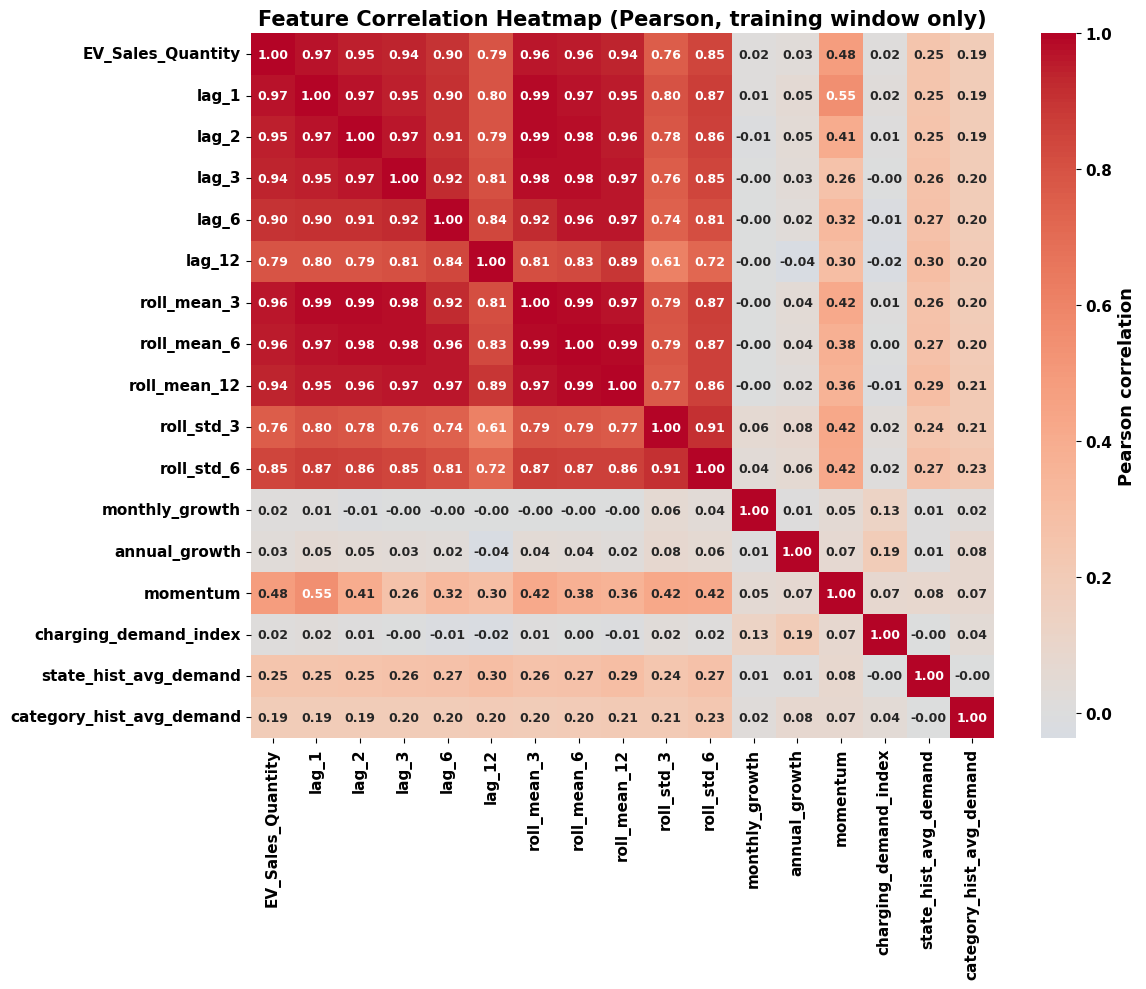

In [19]:


# Correlation Analysis of Engineered Numerical Features


# Selecting  numerical engineered features for correlation analysis
numeric_feats_for_corr = [
    'EV_Sales_Quantity', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_mean_12', 'roll_std_3', 'roll_std_6',
    'monthly_growth', 'annual_growth', 'momentum',
    'charging_demand_index', 'state_hist_avg_demand', 'category_hist_avg_demand'
]

# Computing  Pearson correlation matrix using only  training dataset to prevent data leakage
corr_df = panel.loc[
    panel['Date'] <= TRAIN_END,
    numeric_feats_for_corr
].corr(method='pearson')

# Creating a figure for  correlation heatmap
fig, ax = pltx.subplots(figsize=(12, 10))

# Plotting  Pearson correlation heatmap of  engineered features
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'fontweight': 'bold', 'fontsize': 9},
    cbar_kws={'label': 'Pearson correlation'},
    ax=ax
)

# Setting  title of  correlation heatmap
ax.set_title('Feature Correlation Heatmap (Pearson, training window only)')

# Applying  predefined bold formatting to  correlation heatmap
bold_axes(ax)

# Adjusting  layout for better visualization
pltx.tight_layout()

# Displaying  correlation heatmap
pltx.show()

## Step 7 — Feature Selection Agent
Variance threshold, mutual information, LightGBM importance and RFE  **fit on the training split only**.

In [20]:

# Final modeling dataset preparation without data leakage issue


# Defining the candidate input features for model training
candidate_features = [
    'state_code','category_code','Month','Quarter','Year','Week','sin_month','cos_month',
    'lag_1','lag_2','lag_3','lag_6','lag_12',
    'roll_mean_3','roll_mean_6','roll_mean_12','roll_std_3','roll_std_6',
    'monthly_growth','annual_growth','cagr_approx','momentum',
    'state_x_month','cat_x_month','charging_demand_index','demand_growth_index',
    'state_hist_avg_demand','category_hist_avg_demand'
]

# Defining the target variable for prediction
TARGET = 'EV_Sales_Quantity'

# Identifying history-dependent features that require sufficient historical observations
history_cols = [c for c in candidate_features if c.startswith('lag_') or c.startswith('roll_')]

# Identifying ratio-based and growth-related features that may contain undefined values
ratio_cols = [
    'monthly_growth', 'annual_growth', 'cagr_approx', 'momentum',
    'charging_demand_index', 'demand_growth_index'
]

# Replacing infinite values with missing values and filling missing values with zero
panel[ratio_cols] = panel[ratio_cols].replace([nps.inf, -nps.inf], nps.nan).fillna(0)

# Removing records that do not have sufficient historical observations for lag and rolling features
model_panel = panel.dropna(subset=history_cols).copy()

# Replacing remaining infinite and missing values in the selected candidate features with zero
model_panel[candidate_features] = (
    model_panel[candidate_features]
    .replace([nps.inf, -nps.inf], nps.nan)
    .fillna(0)
)

# Verifying that all states are retained after historical data trimming
assert set(model_panel['State'].unique()) == set(states_list), \
    "a state was dropped — check history_cols"

# Verifying that all vehicle categories are retained after historical data trimming
assert set(model_panel['Vehicle_Category'].unique()) == set(cats_list), \
    "a category was dropped — check history_cols"

# Creating the leakage-free training dataset using records up to the predefined training end date
train_df = model_panel[model_panel['Date'] <= TRAIN_END].copy()

# Creating the testing dataset using the predefined testing period
test_df = model_panel[
    (model_panel['Date'] >= TEST_START) &
    (model_panel['Date'] <= TEST_END)
].copy()

# Creating live dataset for future forecasting using latest available date
live_df = model_panel[model_panel['Date'] == LIVE_DATE].copy()

# Displaying the number of records in the training, testing, and live datasets
print("Train:", train_df.shape,
      "| Test:", test_df.shape,
      "| Live seed:", live_df.shape)

# Creating the training feature matrix and target vector
X_train, y_train = train_df[candidate_features], train_df[TARGET]

# Creating the testing feature matrix and target vector
X_test, y_test = test_df[candidate_features], test_df[TARGET]

Train: (16320, 32) | Test: (2040, 32) | Live seed: (170, 32)


In [21]:


# Feature Selection Techniques: Statistical and Model-Based Methods


# Initializing  Variance Threshold selector to identify zero-variance features
vt = VarianceThreshold(threshold=0.0)

# Training  Variance Threshold selector using only  training dataset
vt.fit(X_train)

# Identifying  zero-variance features that will be removed
low_var_features = [
    f for f, keep in zip(candidate_features, vt.get_support()) if not keep
]

# Displaying  list of zero-variance features
print("Zero-variance features (dropped):", low_var_features)

# Computing MutualInformation scores using only  training dataset
mi_scores = mutual_info_regression(
    X_train,
    y_train,
    random_state=RANDOM_STATE
)

# Ranking features according to their Mutual Information scores in descending order
mi_ranked = pdx.Series(
    mi_scores,
    index=candidate_features
).sort_values(ascending=False)

# Displaying  top 15 features based on Mutual Information scores
print("\nTop 15 by Mutual Information:\n", mi_ranked.head(15))

# Initializing the LightGBM model for feature importance estimation
lgb_imp_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE,
    verbosity=-1
)

# Training  LightGBM model using only  training dataset
lgb_imp_model.fit(X_train, y_train)

# Calculating and ranking feature importance scores obtained from  trained LightGBM model
lgb_ranked = pdx.Series(
    lgb_imp_model.feature_importances_,
    index=candidate_features
).sort_values(ascending=False)

# Displaying top 15most importantfeatures based on LightGBM feature importance
print("\nTop 15 by LightGBM importance:\n", lgb_ranked.head(15))

# Initializing  Recursive Feature Elimination (RFE) selector with a Random Forest estimator
rfe = RFE(
    estimator=RandomForestRegressor(
        n_estimators=60,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    n_features_to_select=18,
    step=2
)

# Training  RFE selector using only  training dataset
rfe.fit(X_train, y_train)

# Selecting  top 18 most informative features identified by RFE
rfe_selected = [
    f for f, keep in zip(candidate_features, rfe.support_) if keep
]

# Displaying the final list of features selected by Recursive Feature Elimination
print("\nRFE-selected features:", rfe_selected)

Zero-variance features (dropped): []

Top 15 by Mutual Information:
 roll_mean_3              0.792887
roll_mean_6              0.789635
lag_1                    0.772628
roll_mean_12             0.751561
roll_std_6               0.718461
lag_2                    0.692133
lag_3                    0.647232
roll_std_3               0.631033
lag_6                    0.561750
momentum                 0.536722
lag_12                   0.437858
charging_demand_index    0.426257
cagr_approx              0.412104
monthly_growth           0.357620
annual_growth            0.325952
dtype: float64

Top 15 by LightGBM importance:
 lag_1                    378
lag_6                    231
roll_mean_6              198
lag_3                    181
lag_12                   174
momentum                 165
roll_mean_3              155
lag_2                    144
roll_std_6               140
roll_std_3               126
sin_month                117
monthly_growth            93
roll_mean_12             

In [24]:


# Final Consensus-Based Feature Selection


# Selecting the top 20 features based on Mutual Information scores
mi_top = set(mi_ranked.head(20).index)

# Selecting the top 20 features based on LightGBM feature importance scores
imp_top = set(lgb_ranked.head(20).index)

# Creating final feature set using the outputs of Variance Threshold,
# Mutual Information, LightGBM feature importance, and Recursive Feature Elimination (RFE)
selected_features = [
    f for f in candidate_features
    if f not in low_var_features
    and (f in mi_top or f in imp_top or f in rfe_selected)
]

# Displaying the total number of selected features out of all candidate features
print(f"Final selected feature count: {len(selected_features)} / {len(candidate_features)}")

# Displaying thefinal list of selected features
print(selected_features)

# Saving  finals selected featurelist as a Pickle file for future model training and inference
with open(f"{MODEL_DIR}/selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

Final selected feature count: 27 / 28
['state_code', 'category_code', 'Month', 'Year', 'Week', 'sin_month', 'cos_month', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_3', 'roll_mean_6', 'roll_mean_12', 'roll_std_3', 'roll_std_6', 'monthly_growth', 'annual_growth', 'cagr_approx', 'momentum', 'state_x_month', 'cat_x_month', 'charging_demand_index', 'demand_growth_index', 'state_hist_avg_demand', 'category_hist_avg_demand']


## Step 8 — Scaling and Encoding Agent
StandardScaler and LabelEncoder are fit on train data

In [52]:

# Feature Scaling and Categorical Encoding


# Initializing StandardScaler for feature normalization
scaler = StandardScaler()

# Fitting the StandardScaler using only the training dataset
scaler.fit(train_df[selected_features])

# Transforming the training dataset using the fitted StandardScaler
# Scale selected training features using fitted scaler
# Preserve selected feature names and training data indices
# Create a pandas DataFrame from the scaled training features
X_train_scaled = pdx.DataFrame(
    scaler.transform(train_df[selected_features]),
    columns=selected_features,
    index=train_df.index
)

# Transforming the testing dataset using the fitted StandardScaler
X_test_scaled = pdx.DataFrame(
    scaler.transform(test_df[selected_features]),
    columns=selected_features,
    index=test_df.index
)

# Creating a dictionary to store the fitted Label Encoders
label_encoders = {}

# Encoding the categorical features
for col in ['State', 'Vehicle_Category']:

    # Initializing the Label Encoder for the current categorical feature
    le = LabelEncoder()

    # Fitting the Label Encoder using only the training dataset categories
    le.fit(train_df[col])

    # Saving the fitted Label Encoder for future use
    label_encoders[col] = le

    # Encoding the categorical feature for the training, testing, and live datasets
    # Assigning the value -1 to any unseen category (expected to be none in this dataset)
    for d in [train_df, test_df, live_df]:
        d[col + '_le'] = d[col].map(
            lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
        )

# Saving the fitted StandardScaler as a Pickle file
with open(f"{MODEL_DIR}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Saving the fitted Label Encoders as a Pickle file
with open(f"{MODEL_DIR}/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

# Saving the complete list of input feature columns as a Pickle file
with open(f"{MODEL_DIR}/feature_columns.pkl", "wb") as f:
    pickle.dump(candidate_features, f)

# Displaying a confirmation message indicating that the scaler and encoders were trained using only the training dataset and successfully saved
print("Scaler and encoders fit on TRAIN only, saved to", MODEL_DIR)


Scaler and encoders fit on TRAIN only, saved to /kaggle/working/models


## Step 9 — Forecasting Agent
Candidate models: Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost. Hyperparameter search uses TimeSeriesSplit **within the training window only**

In [29]:

# Model Training and Hyperparameter Tuning


# Resetting train_df's row index so that positional indices used below (np.where / RandomizedSearchCV)
# line up exactly with Xtr_sel / ytr, regardless of how train_df's rows happen to be ordered
train_df = train_df.reset_index(drop=True)

# Creating the training feature matrix and target vector using the selected features
Xtr_sel, ytr = train_df[selected_features], train_df[TARGET]

# Creating the testing feature matrix and target vector using the selected features
Xte_sel, yte = test_df[selected_features], test_df[TARGET]


#  panel-aware (date-threshold) CV splits instead of a raw TimeSeriesSplit on rows
# Extracting the sorted array of unique calendar dates present in the training set
train_dates_sorted = nps.sort(train_df['Date'].unique())

# Using TimeSeriesSplit on the small array of unique dates (not on the rows) to get rolling-origin cutoffs
date_tscv = TimeSeriesSplit(n_splits=4)

# Building the actual (train_row_idx, val_row_idx) folds by mapping each date-fold back onto train_df rows
cv_splits = []
for train_date_pos, val_date_pos in date_tscv.split(train_dates_sorted):
    fold_train_dates = train_dates_sorted[train_date_pos]
    fold_val_dates = train_dates_sorted[val_date_pos]
    fold_train_idx = nps.where(train_df['Date'].isin(fold_train_dates))[0]
    fold_val_idx = nps.where(train_df['Date'].isin(fold_val_dates))[0]
    cv_splits.append((fold_train_idx, fold_val_idx))

# Sanity-printing each fold's date ranges to confirm training dates are strictly before validation dates
print("Panel-aware rolling-origin CV folds (dates, not row position):")
for fi, (tr_idx, va_idx) in enumerate(cv_splits):
    print(f"  Fold {fi}: train <= {train_df.loc[tr_idx, 'Date'].max().date()} | "
          f"val {train_df.loc[va_idx, 'Date'].min().date()} -> {train_df.loc[va_idx, 'Date'].max().date()} "
          f"({len(tr_idx)} train rows / {len(va_idx)} val rows)")

# Creating a dictionary to store the trained candidate models
candidate_models = {}

# Initializing the hyperparameter search space for the Random Forest Regressor
rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 3, 5]
}

# Configuring RandomizedSearchCV for Random Forest with the panel-aware date-based CV folds
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
    n_iter=5,
    cv=cv_splits,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Training the hyperparameter search for Random Forest with the training dataset only
rf_search.fit(Xtr_sel, ytr)

# Storing the best Random Forest model from the hyperparameter tuning process
candidate_models['RandomForest'] = rf_search.best_estimator_

# Showing the best hyperparameters for the Random Forest model
print('RandomForest best params:', rf_search.best_params_)

# Initializing the hyperparameter search space for the Extra Trees Regressor
et_params = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 3, 5]
}

# Configuring RandomizedSearchCV for Extra Trees with the panel-aware date-based CV folds
et_search = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    et_params,
    n_iter=5,
    cv=cv_splits,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Training the hyperparameter search for Extra Trees with the training dataset only
et_search.fit(Xtr_sel, ytr)

# Storing the best Extra Trees model from the hyperparameter tuning process
candidate_models['ExtraTrees'] = et_search.best_estimator_

# Showing the best hyperparameters for the Extra Trees model
print('ExtraTrees best params:', et_search.best_params_)

Panel-aware rolling-origin CV folds (dates, not row position):
  Fold 0: train <= 2016-08-01 | val 2016-09-01 -> 2018-03-01 (3400 train rows / 3230 val rows)
  Fold 1: train <= 2018-03-01 | val 2018-04-01 -> 2019-10-01 (6630 train rows / 3230 val rows)
  Fold 2: train <= 2019-10-01 | val 2019-11-01 -> 2021-05-01 (9860 train rows / 3230 val rows)
  Fold 3: train <= 2021-05-01 | val 2021-06-01 -> 2022-12-01 (13090 train rows / 3230 val rows)
RandomForest best params: {'n_estimators': 200, 'min_samples_leaf': 3, 'max_depth': 12}
ExtraTrees best params: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_depth': 8}


In [30]:





xgb_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0, tree_method='hist'),  # hist = much faster
    xgb_params,
    n_iter=15,              # 6 -> 15 (fast but wider than original)
    cv=cv_splits,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_search.fit(Xtr_sel, ytr)
candidate_models['XGBoost'] = xgb_search.best_estimator_
print('XGBoost best params:', xgb_search.best_params_)

lgb_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8, -1],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'num_leaves': [15, 31, 63],
    'subsample': [0.8, 1.0]
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1),
    lgb_params,
    n_iter=15,
    cv=cv_splits,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lgb_search.fit(Xtr_sel, ytr)
candidate_models['LightGBM'] = lgb_search.best_estimator_
print('LightGBM best params:', lgb_search.best_params_)

cat_params = {
    'iterations': [300, 500, 700],
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7]
}

cat_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=RANDOM_STATE, verbose=False, thread_count=-1),
    cat_params,
    n_iter=15,
    cv=cv_splits,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
cat_search.fit(Xtr_sel, ytr)
candidate_models['CatBoost'] = cat_search.best_estimator_
print('CatBoost best params:', cat_search.best_params_)

XGBoost best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
LightGBM best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03}
CatBoost best params: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 4}


## Step 10 — Model Selection
Evaluate every candidate on the **test set only**. Best model chosen by validation RMSE.

In [32]:

# Model Performance Evaluation


# Function definition for model performance evaluation with RMSE, MAE, MAPE, and R² calculation
def _score(y_true, y_pred):

    # Constrain predictions to non-negative values for realistic EV demand prediction
    y_pred = nps.clip(y_pred, 0, None)

    # Calculation of Root Mean Squared Error (RMSE)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5

    # Calculation of Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_true, y_pred)

    # Calculation of Coefficient of Determination (R² Score)
    r2 = r2_score(y_true, y_pred)

    # Find records with non-zero target value for safety of MAPE calculation
    mask = y_true > 0

    # Calculation of Mean Absolute Percentage Error (MAPE)
    mape = (
        nps.abs((y_true[mask] - y_pred[mask]) / y_true[mask]).mean() * 100
        if mask.sum() else nps.nan
    )

    # Return evaluation metrics
    return rmse, mae, mape, r2

# List of candidate models' test performance
test_results = []

# Model performance evaluation of all trained candidate models on test set
for name, model in candidate_models.items():

    # Generate predictions for current model
    pred = model.predict(Xte_sel)

    # Calculate performance metrics for predictions
    rmse, mae, mape, r2 = _score(yte.values, pred)

    # Record current model's test performance metrics
    test_results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE(%)': mape,
        'R2': r2
    })

# Creation of DataFrame that contains performance comparison of all candidate models on test set and sort it by RMSE
test_results_df = pdx.DataFrame(test_results).sort_values('RMSE')

# Test performance comparison of all candidate models
print(test_results_df.to_string(index=False))

# Model selection based on lowest RMSE on test set
best_model_name = test_results_df.iloc[0]['Model']

# Name of selected model on test set
print(f"\n Best model on test: {best_model_name}")

       Model       RMSE        MAE    MAPE(%)       R2
RandomForest 717.539826 180.893450  72.355903 0.906034
  ExtraTrees 719.871004 181.555077  65.971712 0.905423
    CatBoost 758.503346 191.554067 104.358189 0.894999
    LightGBM 827.960650 205.666986  65.352242 0.874889
     XGBoost 977.982666 225.348293  80.830834 0.825442

 Best model on test: RandomForest


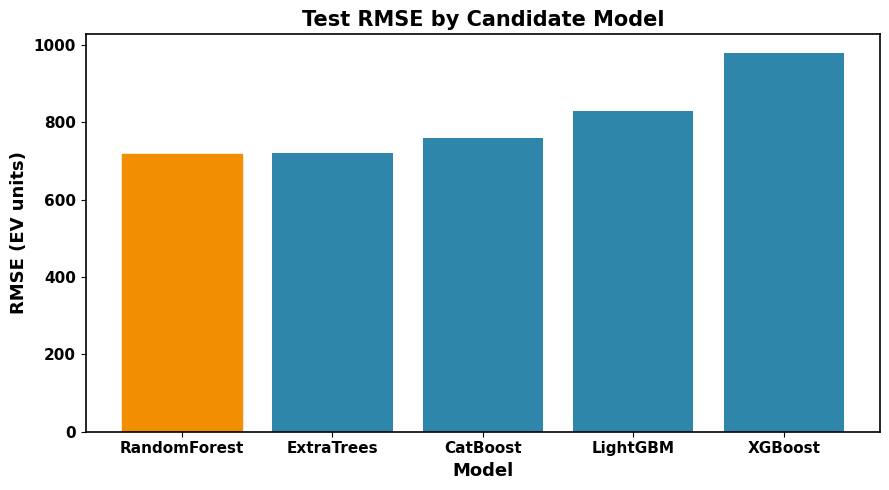

In [33]:

# Test Performance Visualization


# Building the figure and axis for plotting RMSE of test
fig, ax = pltx.subplots(figsize=(9, 5))

# Plotting RMSE of all models on the bar chart
bars = ax.bar(test_results_df['Model'], test_results_df['RMSE'], color='#2E86AB')

# Identifying the best performing model by coloring differently
bars[list(test_results_df['Model']).index(best_model_name)].set_color('#F18F01')

# Assigning title to the test performance plot
ax.set_title('Test RMSE by Candidate Model')

# Assigning x-axis label
ax.set_xlabel('Model')

# Assigning y-axis label
ax.set_ylabel('RMSE (EV units)')

# Applying bold formatting to the plot axes
bold_axes(ax)

# Arranging the layout of the plot
pltx.tight_layout()

# Displaying the test RMSE comparison chart
pltx.show()

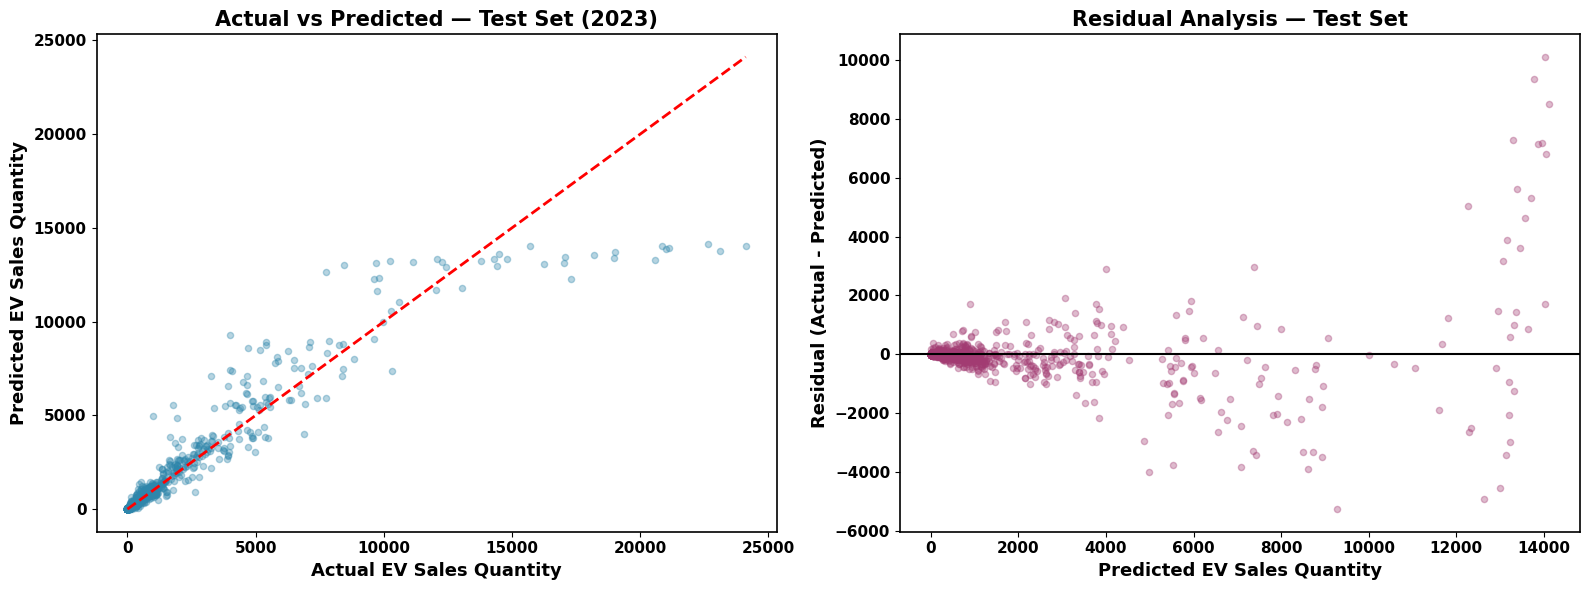

In [35]:
# Visualizing the predictions and residuals of the final test set


# Selecting the best performing model based on test RMSE ranking
best_model = candidate_models[best_model_name]

# Generating predictions for the final selected best model on the test set
test_pred = nps.clip(best_model.predict(Xte_sel), 0, None)

# Computing residuals (Actual - Predicted) for the test set
residuals = yte.values - test_pred

# Figure and subplots for test predictions and residual analysis
fig, axes = pltx.subplots(1, 2, figsize=(16, 6))

# Plots the actual vs predicted EV sales values for the unseen test data set
axes[0].scatter(yte.values, test_pred, alpha=0.35, color='#2E86AB', s=20)

# Defines the axis limits for the ideal reference line
lims = [0, max(yte.max(), test_pred.max())]

# Plots the reference line for an ideal prediction (Actual = Predicted)
axes[0].plot(lims, lims, color='red', linewidth=2, linestyle='--')

# Title for the actual vs predicted plot
axes[0].set_title('Actual vs Predicted — Test Set (2023)')

# X-axis label for the actual vs predicted plot
axes[0].set_xlabel('Actual EV Sales Quantity')

# Y-axis label for the actual vs predicted plot
axes[0].set_ylabel('Predicted EV Sales Quantity')

# Makes the axes labels bold for the first subplot
bold_axes(axes[0])

# Plots the residuals vs the predicted EV sales values
axes[1].scatter(test_pred, residuals, alpha=0.35, color='#A23B72', s=20)

# Plots the reference line for zero residuals
axes[1].axhline(0, color='black', linewidth=1.5)

# Title for the residual analysis plot
axes[1].set_title('Residual Analysis — Test Set')

# X-axis label for the residual analysis plot
axes[1].set_xlabel('Predicted EV Sales Quantity')

# Y-axis label for the residual analysis plot
axes[1].set_ylabel('Residual (Actual - Predicted)')

# Makes the axes labels bold for the second subplot
bold_axes(axes[1])

# Adjusts the layout for better visualization
pltx.tight_layout()

# Displays the final test predictions and residual analysis plots
pltx.show()

## Step 11 — Infrastructure Planning Agent
Recursive multi-step forecast (3 / 6 / 12 months) per (State, Vehicle_Category) series,

In [39]:
# Multi-Horizon Recursive EV Demand Forecasting


# Selecting the final model to be used for forecasting, based on best test-set performance
final_model = candidate_models[best_model_name]

# Defining the forecasting horizons (in months)
HORIZONS = [3, 6, 12]

# Preparing the initial seed state using the latest available historical observations

# Selecting the required columns for recursive forecasting while omitting regenerated temporal features
seed_cols = ['State','Vehicle_Category','state_code','category_code','Year','Month'] + \
            [c for c in selected_features if c not in ('Month','Quarter','Year','Week','sin_month','cos_month','state_x_month','cat_x_month')]

# Preparing a copy of the latest available data to kick off the forecasting procedure
seed_state = live_df[['State','Vehicle_Category','Date','EV_Sales_Quantity'] + selected_features].copy()

# Creating a list to collect the forecast results for each forecasting horizon
forecast_rows = []

# Creating a dictionary to keep track of the rolling historical demands for each state-category pair
history = {}

# Initializing the historical demand sequence for each state-category pair
for _, r in seed_state.iterrows():

    # Creating a unique key for each state and vehicle category pair
    key = (r['State'], r['Vehicle_Category'])

    # Extracting the latest historical lag values for initializing recursive forecasting
    history[key] = [r.get(f'lag_{L}', 0) for L in [12,11,10,9,8,7,6,5,4,3,2,1]]

    # Filling missing historical values with zero to enable stable forecasting
    history[key] = [v if pdx.notna(v) else 0 for v in history[key]]


# cagr_approx made it into selected_features (27/28 candidate features kept, including it),
# so the model was TRAINED to use real CAGR signal: (lag_1 / roll_mean_12) (1/n_years) - 1.
min_year_lookup = panel.groupby(['State', 'Vehicle_Category'])['Year'].min().to_dict()

# Initializing the forecasting start date based on the live reference date
cur_date = pdx.Timestamp(LIVE_DATE)

# Iteratively generating forecasts for each future month
for step in range(1, max(HORIZONS) + 1):

    # Increasing the forecasting date by one month
    cur_date = cur_date + pdx.DateOffset(months=1)

    # Creating a temporary list to keep the forecast records for the current forecasting iteration
    step_rows = []

    # Iteratively iterating through each state-category pair
    for key in history:

        # Extracting the state and vehicle category codes
        state, cat = key

        # Extracting the historical demand sequence for the current series
        hist = history[key]

        # Extracting the required lag features from the historical demand sequence
        lag_1, lag_2, lag_3 = hist[-1], hist[-2], hist[-3]
        lag_6, lag_12 = hist[-6], hist[-12]

        # Computing rolling mean statistics from historical demand
        roll_mean_3 = nps.mean(hist[-3:])
        roll_mean_6 = nps.mean(hist[-6:])
        roll_mean_12 = nps.mean(hist[-12:])

        # Computing rolling standard deviation statistics from historical demand
        roll_std_3 = nps.std(hist[-3:])
        roll_std_6 = nps.std(hist[-6:])

        # Computing the monthly demand growth rate
        monthly_growth = (lag_1 - lag_2) / lag_2 if lag_2 else 0

        # Computing the annual demand growth rate
        annual_growth = (lag_1 - lag_12) / lag_12 if lag_12 else 0

        # Computing the demand momentum feature
        momentum = lag_1 - lag_3

        # Computing the charging demand index
        cdi = lag_1 / roll_mean_12 if roll_mean_12 else 0

        # Recomputing cagr_approx with the same formula used at training time ,
        # using this series' own first-observed year and the current forecast year for n_years
        first_year = min_year_lookup.get(key, cur_date.year)
        n_years_val = max(cur_date.year - first_year, 1)
        if roll_mean_12 and roll_mean_12 > 0 and lag_1 >= 0:
            cagr_val = (lag_1 / roll_mean_12) ** (1 / n_years_val) - 1
        else:
            cagr_val = 0.0

        # Extracting the encoded state code
        state_code = int(train_df.loc[train_df['State'] == state, 'state_code'].iloc[0])

        # Extracting the encoded vehicle category code
        category_code = int(train_df.loc[train_df['Vehicle_Category'] == cat, 'category_code'].iloc[0])

        # Constructing the full feature vector for predicting the next time step
        row = {
            'State': state,
            'Vehicle_Category': cat,
            'Date': cur_date,
            'state_code': state_code,
            'category_code': category_code,
            'Month': cur_date.month,
            'Quarter': (cur_date.month - 1)//3 + 1,
            'Year': cur_date.year,
            'Week': int(cur_date.isocalendar().week),
            'sin_month': nps.sin(2*nps.pi*cur_date.month/12),
            'cos_month': nps.cos(2*nps.pi*cur_date.month/12),
            'lag_1': lag_1,
            'lag_2': lag_2,
            'lag_3': lag_3,
            'lag_6': lag_6,
            'lag_12': lag_12,
            'roll_mean_3': roll_mean_3,
            'roll_mean_6': roll_mean_6,
            'roll_mean_12': roll_mean_12,
            'roll_std_3': roll_std_3,
            'roll_std_6': roll_std_6,
            'monthly_growth': monthly_growth,
            'annual_growth': annual_growth,
            'momentum': momentum,
            'state_x_month': state_code * cur_date.month,
            'cat_x_month': category_code * cur_date.month,
            'charging_demand_index': cdi,
            'demand_growth_index': annual_growth,
            'state_hist_avg_demand': state_hist_avg.get(state, 0),
            'category_hist_avg_demand': cat_hist_avg.get(cat, 0),
            'cagr_approx': cagr_val,
        }

        step_rows.append(row)

    # Creating a DataFrame consisting of the forecast records of the current forecasting iteration
    step_df = pdx.DataFrame(step_rows)

    # Filling invalid values and missing values before making predictions
    step_df[selected_features] = step_df[selected_features].replace([nps.inf, -nps.inf], nps.nan).fillna(0)

    # Making demand predictions based on the trained forecasting model
    step_df['pred'] = nps.clip(final_model.predict(step_df[selected_features]), 0, None)

    # Storing the current forecasting horizon
    step_df['horizon_month'] = step

    for _, r in step_df.iterrows():

        # Adding the new historical value to the historical demand sequence
        history[(r['State'], r['Vehicle_Category'])].append(r['pred'])

        # Retaining only the latest twelve observations for recursive forecasting
        history[(r['State'], r['Vehicle_Category'])] = history[(r['State'], r['Vehicle_Category'])][-12:]

    # Collecting the forecast results for the specified forecasting horizons
    if step in HORIZONS:
        forecast_rows.append(step_df.assign(cum_horizon=step))

# Merging the forecasts from all selected horizons into a single DataFrame
forecast_df = pdx.concat(forecast_rows, ignore_index=True)

# Printing out a message after successfully performing recursive forecasting
print("Recursive forecast generated for horizons:", HORIZONS)



Recursive forecast generated for horizons: [3, 6, 12]


In [38]:

# Showing a preview of the produced multi-horizon forecast results — sample from each horizon
for h in HORIZONS:
    print(f"\n=== Horizon: {h} months ===")
    display(
        forecast_df[forecast_df['cum_horizon'] == h]
        [['State', 'Vehicle_Category', 'cum_horizon', 'cagr_approx', 'pred']]
        .head(5)
    )


=== Horizon: 3 months ===


,State,Vehicle_Category,cum_horizon,cagr_approx,pred
0,Andaman & Nicobar Island,2-Wheelers,3,0.180426,12.670366
1,Andaman & Nicobar Island,3-Wheelers,3,0.265636,3.801533
2,Andaman & Nicobar Island,4-Wheelers,3,0.070021,1.740170
3,Andaman & Nicobar Island,Bus,3,0.215024,3.054734
4,Andaman & Nicobar Island,Others,3,0.211591,3.019563



=== Horizon: 6 months ===


,State,Vehicle_Category,cum_horizon,cagr_approx,pred
170,Andaman & Nicobar Island,2-Wheelers,6,0.127662,25.818967
171,Andaman & Nicobar Island,3-Wheelers,6,0.162417,11.848668
172,Andaman & Nicobar Island,4-Wheelers,6,0.039302,2.091662
173,Andaman & Nicobar Island,Bus,6,0.189242,4.883879
174,Andaman & Nicobar Island,Others,6,0.182329,3.914642



=== Horizon: 12 months ===


,State,Vehicle_Category,cum_horizon,cagr_approx,pred
340,Andaman & Nicobar Island,2-Wheelers,12,0.072624,64.365510
341,Andaman & Nicobar Island,3-Wheelers,12,0.074668,31.782643
342,Andaman & Nicobar Island,4-Wheelers,12,0.079921,6.599934
343,Andaman & Nicobar Island,Bus,12,0.069319,11.417194
344,Andaman & Nicobar Island,Others,12,0.064552,8.182316


        State  Total_Priority_Score
Uttar Pradesh              1.751581
    Rajasthan              1.507025
   Tamil Nadu              1.343963
        Delhi              1.312049
  Maharashtra              1.208737
        Bihar              1.206407
       Kerala              1.206103
    Karnataka              1.199456
       Odisha              1.160580
      Gujarat              1.156648


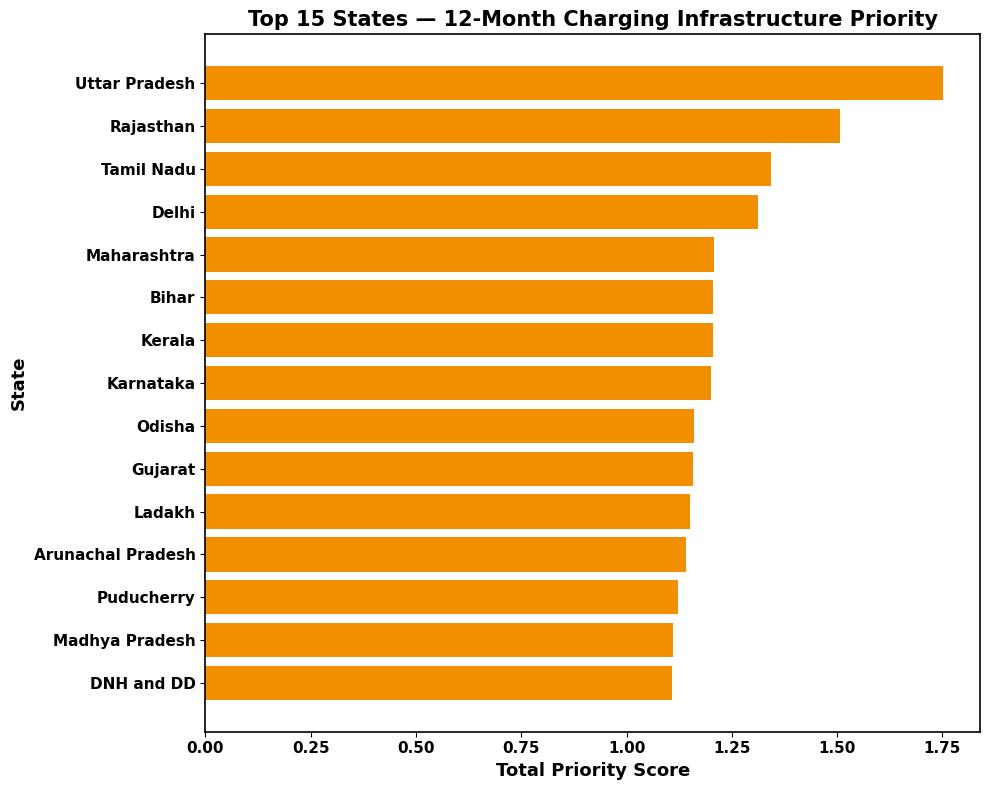

In [40]:


# Infrastructure Priority and State Ranking for Charging Infrastructure


# Selecting the 12-month forecast records for planning of charging infrastructure
infra_12m = forecast_df[forecast_df['cum_horizon'] == 12].copy()

# Computing the infrastructure priority score based on forecast demand, demand index, and growth in demand index
infra_12m['priority_score'] = (
    0.5 * (infra_12m['pred'] / infra_12m['pred'].max()) +
    0.3 * (infra_12m['charging_demand_index'] / infra_12m['charging_demand_index'].replace(0, nps.nan).max()) +
    0.2 * (infra_12m['demand_growth_index'].clip(lower=0) /
           infra_12m['demand_growth_index'].clip(lower=0).replace(0, nps.nan).max())
).fillna(0)

# Computing the upper and lower threshold of infrastructure priority score using quantiles
q_hi, q_lo = infra_12m['priority_score'].quantile([0.66, 0.33])

# Classification of state-category combination as having Low, Medium, or High infrastructure priority
infra_12m['priority_category'] = pdx.cut(
    infra_12m['priority_score'],
    bins=[-1, q_lo, q_hi, 2],
    labels=['Low', 'Medium', 'High']
)

# Computation of infrastructure priority score for each state and ranking the states based on descending order of score
state_ranking = (
    infra_12m.groupby('State')['priority_score']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Renaming the rank dataframe columns
state_ranking.columns = ['State', 'Total_Priority_Score']

# Getting the Top 10 states for charging infrastructure priority score
print(state_ranking.head(10).to_string(index=False))

# Creation of figure and axis for plotting state-wise infrastructure priority rank
fig, ax = pltx.subplots(figsize=(10, 8))

# Selection of top 15 states for visualization
top15 = state_ranking.head(15)

# Plotting of the Top 15 states' ranks as bar plot
ax.barh(top15['State'][::-1], top15['Total_Priority_Score'][::-1], color='#F18F01')

# Setting the title for the infrastructure priority rank plot
ax.set_title('Top 15 States — 12-Month Charging Infrastructure Priority')

# Setting the xlabel of the plot
ax.set_xlabel('Total Priority Score')

# Setting the ylabel of the plot
ax.set_ylabel('State')

# Setting bold face for the plot axes
bold_axes(ax)

# Arrangement of plot layout
pltx.tight_layout()

# Visualization of charging infrastructure priority rank chart
pltx.show()

## Step 12 — LLM Decision Agent
Interprets the ML output and writes planning recommendations — it never predicts demand itself, only explains what the forecasting agent already produced. Uses **Qwen2.5-3B-Instruct** with automatic fallback to a deterministic template  a real LLM call and a total pipeline failure are very different things

In [41]:


# Load and Initialize Large Language Model (LLM)


# Defining the Hugging Face model ID for the instruction-tuned Qwen LLM
LLM_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

# Initializing the LLM inference pipeline to None by default
llm_pipe = None

# Trying to load and initialize the Large Language Model
try:

    # Importing the necessary deep learning and Hugging Face libraries
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline as hf_pipeline

    # Initializing the GPU availability flag
    use_cuda = False

    # Testing whether GPU support is available
    if torch.cuda.is_available():
        try:
            # Ensuring that the GPU is working properly through a lightweight CUDA test
            _ = (torch.tensor([1.0]).cuda() + 1).cpu()

            # Activating GPU usage in case of successful validation of the CUDA environment
            use_cuda = True

        # Warning about unavailable GPU and switching to the CPU mode in case of missing or incompatible GPU
        except Exception as e:
            print(f"CUDA present but unusable ({type(e).__name__}: {e}) — using CPU for the LLM.")

    # Loading tokenizer for the chosen Large Language Model
    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_ID)

    # Setting  end of sequence token as the padding token in case of lacking the latter
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Loading the pretrained Large Language Model with the right computation device and precision
    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL_ID,
        torch_dtype=torch.float16 if use_cuda else torch.float32,
        device_map="auto" if use_cuda else "cpu"
    )

    # Setting up the generation parameters using the tokenizer padding token
    llm_model.generation_config.pad_token_id = tokenizer.pad_token_id

    # Setting up the text generation inference pipeline for recommendation generation
    # Initializing a text generation pipeline based on the Hugging Face model
# Configuring selected tokenizer and language model
# Restricting generation responses to 180 tokens
# Not using sampling to generate text
# Configuring padding token of tokenizer for generation

    llm_pipe = hf_pipeline(
        "text-generation",
        model=llm_model,
        tokenizer=tokenizer,
        max_new_tokens=180,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        device=0 if use_cuda else -1
    )

    # Warning the user about the computation device used for the LLM
    print(f"Qwen2.5-3B-Instruct loaded on {'GPU' if use_cuda else 'CPU (slower, but stable)' }.")

# Catching any model loading/initialization errors
except Exception as e:

    # Warning the user about the inability to load the LLM
    print(f"LLM unavailable in this environment ({type(e).__name__}: {e}).")

    # Fallback to deterministic template-based recommendation generation
    print("Falling back to a deterministic template-based recommendation generator.")

    # Deactivating the LLM pipeline after the fallback initialization
    llm_pipe = None

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Qwen2.5-3B-Instruct loaded on GPU.


In [42]:


# LLM-Based Charging Infrastructure Recommendation Generation


# Getting the top 5 states according to their infrastructure priority
top5_states = state_ranking.head(5)

# Looping through each of the top 5 priority states
for _, row in top5_states.iterrows():

    # Extracting the name of the current state
    state = row['State']

    # Getting the infrastructure forecast records for the current state
    state_rows = infra_12m[infra_12m['State'] == state]

    # Extracting the type of the vehicle with the greatest demand of EVs forecast
    top_cat = state_rows.sort_values('pred', ascending=False).iloc[0]

    # Building the prompt for the Large Language Model with the forecast and infrastructure indicators
    prompt = (
        f"You are an EV charging-infrastructure planning assistant. State: {state}. "
        f"12-month forecast EV demand: {top_cat['pred']:.0f} units (category: {top_cat['Vehicle_Category']}). "
        f"Charging Demand Index: {top_cat['charging_demand_index']:.2f}. "
        f"Priority category: {top_cat['priority_category']}. "
        f"In 2-3 sentences, recommend where and how urgently to expand charging infrastructure."
    )

    # Evaluating the level of infrastructure expansion urgency by the priority category
    urgency = {
        'High': 'immediate',
        'Medium': 'near-term',
        'Low': 'monitored, lower-urgency'
    }[str(top_cat['priority_category'])]

    # Building the recommendation with the deterministic template-based approach as the backup option
    template_recommendation = (
        f"{state} shows {urgency} charging-infrastructure need, driven mainly by {top_cat['Vehicle_Category']} "
        f"demand (forecast {top_cat['pred']:.0f} units over 12 months, demand index {top_cat['charging_demand_index']:.2f}). "
        f"Recommend prioritizing high-density urban corridors and major intercity routes for new charging capacity."
    )

    # Initializing the recommendation with the deterministic template-based approach output
    recommendation = template_recommendation

    # Initializing the LLM usage indicator
    used_llm = False

    # Verifying the availability of the Large Language Model
    if llm_pipe is not None:
        try:

            # Getting the recommendation from the LLM
            out = llm_pipe(prompt)[0]['generated_text']

            # Extracting only the response part from the entire output of the model
            recommendation = out[len(prompt):].strip()

            # Noting that the recommendation has been generated with the LLM
            used_llm = True

        # Handling any errors of the LLM generation without breaking the recommendation flow
        except Exception as e:

            # Warning the user and switching to the template-based recommendation for the current state
            print(f"[{state}] LLM generation failed ({type(e).__name__}: {e}) — using template fallback.")

    # Showing the name of the current state and the source of recommendation (LLM or template fallback)
    print(f"=== {state} {'(LLM)' if used_llm else '(template fallback)'} ==")

    # Showing the charging infrastructure recommendation
    print(recommendation)

    # Printing an empty line to make the recommendation output more readable
    print()

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the docum

=== Uttar Pradesh (LLM) ==
Given the high priority category and the forecasted demand for 3-wheelers in Uttar Pradesh, it is crucial to prioritize expanding charging infrastructure in urban centers and major highways. This expansion should focus on strategically locating fast-charging stations to meet the growing demand efficiently, ensuring a seamless charging experience for electric three-wheelers. Immediate attention is warranted to address this critical need.



[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Rajasthan (LLM) ==
Given the high 12-month forecast of 13,164 electric two-wheelers in Rajasthan and a Charging Demand Index of 1.59 indicating significant demand, urgent expansion of charging infrastructure is required, particularly in urban centers and key transportation hubs. This will ensure that the growing fleet has reliable access to charging points, supporting sustainable mobility and reducing grid stress. 

To address this, prioritize expanding public charging stations in major cities like Jaipur, Udaipur, and Jodhpur, as well as strategic locations such as bus terminals, train stations, and commercial areas. Additionally, encourage private sector involvement through partnerships and subsidies to accelerate deployment of fast-charging networks. 

This targeted approach will help meet the growing demand for EV charging while ensuring a smooth transition towards cleaner transportation. 

(Note: The actual locations and scale of expansion would need detailed analysis based on

[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Tamil Nadu (LLM) ==
Given the high 12-month forecast of 13,205 electric two-wheelers in Tamil Nadu and a Charging Demand Index of 1.59 indicating significant demand, urgent expansion of charging infrastructure is required, particularly in urban areas such as major cities and towns where these vehicles will predominantly be used. This expansion should include both fast-charging stations and public charging points to meet the growing demand efficiently. 

(Note: The Charging Demand Index of 1.59 suggests that the actual demand could be higher than the forecasted number, emphasizing the need for proactive planning and rapid deployment of charging infrastructure.)



[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Delhi (LLM) ==
Given the high 12-month forecast of 13,175 electric two-wheelers in Delhi and a Charging Demand Index of 1.35 indicating higher than average demand, we urgently need to expand charging infrastructure, particularly in densely populated areas like residential zones and commercial hubs. This expansion should prioritize public charging stations to ensure accessibility for all users, especially those who may not have access to personal charging solutions.

=== Maharashtra (LLM) ==
Given the high 12-month forecast of 13,444 electric two-wheelers in Maharashtra and a Charging Demand Index of 1.04 indicating strong demand, it is urgent to expand charging infrastructure, particularly in urban centers and key transportation hubs. This expansion should include both public and private charging stations to meet the growing needs efficiently. 

(Note: The Charging Demand Index of 1.04 suggests that the demand for charging points is slightly higher than the current supply, making i

## Step 13 — Explainability Agent
SHAP applied to the final model — global importance, one local waterfall, one force plot.

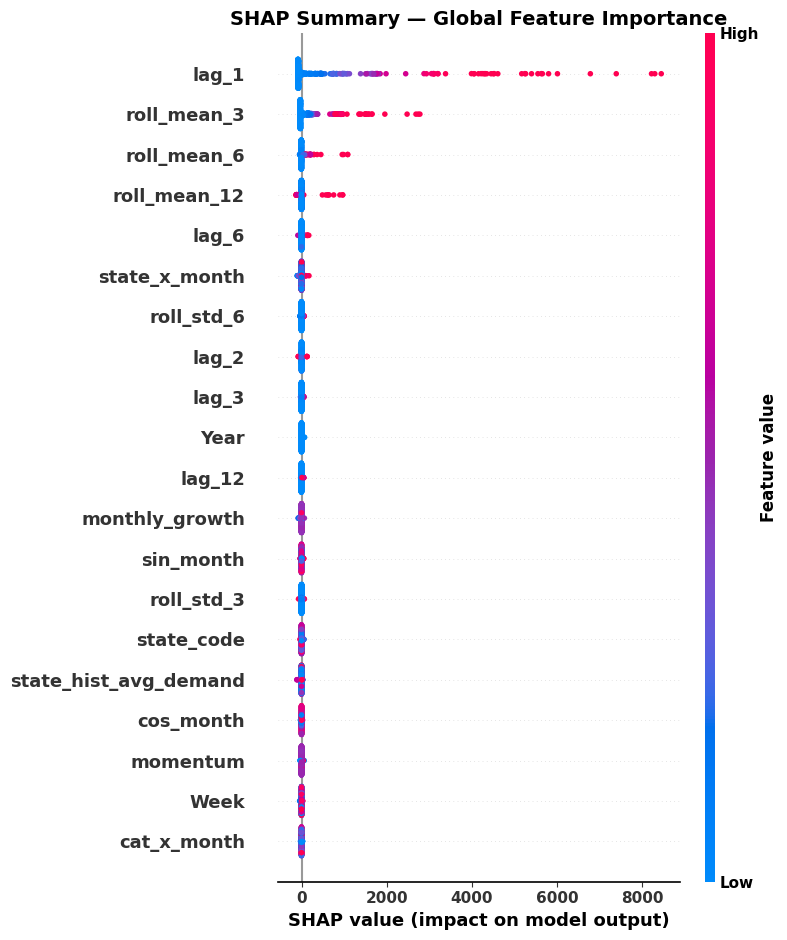

In [43]:


# Explainability of Models Using SHAP


# Loading SHAP library for interpretability of models
import shap

# Initializing the TreeExplainer of SHAP for the trained tree-based model
explainer = shap.TreeExplainer(final_model)

# Sample data selection from the unseen test data for SHAP analysis
shap_sample = Xte_sel.sample(min(500, len(Xte_sel)), random_state=RANDOM_STATE)

# Calculating the SHAP values for the selected test samples
shap_values = explainer.shap_values(shap_sample)

# Initializing the figure for the SHAP plot
pltx.figure(figsize=(10, 8))

# Plotting the SHAP summary plot for global feature importance
shap.summary_plot(shap_values, shap_sample, show=False)

# Defining the title for the SHAP plot
pltx.title('SHAP Summary — Global Feature Importance', fontweight='bold', fontsize=14)

# Layout adjustment for better visualization
pltx.tight_layout()

# Visualizing the SHAP global feature importance plot
pltx.show()

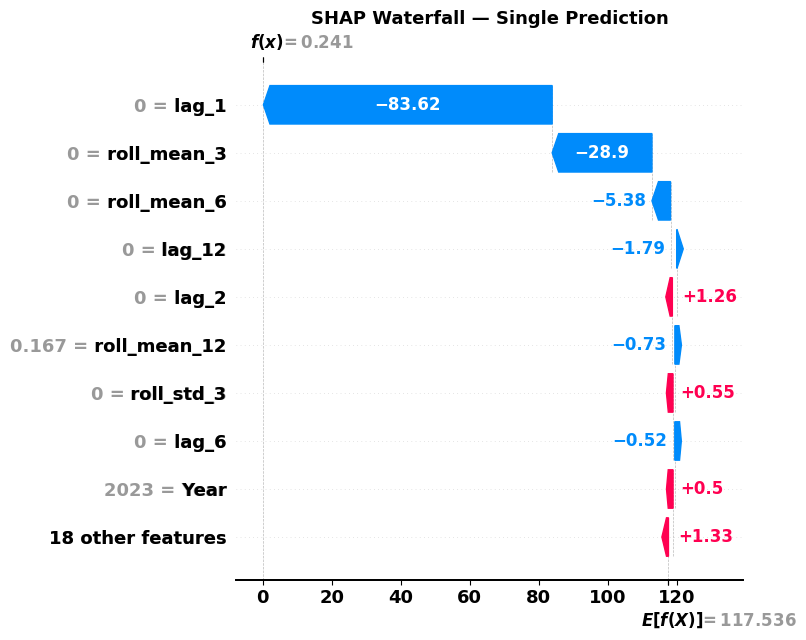

In [44]:


# Explanation of the Local Prediction using SHAP Waterfall Plot


# Normalizing the SHAP Expected Value to scalar for consistency among all kinds of tree-based algorithms
base_value = float(nps.ravel(explainer.expected_value)[0])

# Choosing an example to explain the local prediction
row_idx = 0

# Constructing the explanation of SHAP for the prediction chosen
exp = shap.Explanation(
    values=shap_values[row_idx],
    base_values=base_value,
    data=shap_sample.iloc[row_idx],
    feature_names=selected_features
)

# Initializing  SHAP waterfall plot
pltx.figure(figsize=(10, 7))

# Creating  SHAP waterfall plot to interpret chosen prediction
shap.plots.waterfall(exp, show=False)

# Specifying  title of the SHAP waterfall plot
pltx.title('SHAP Waterfall — Single Prediction', fontweight='bold', fontsize=13)

# Improving  plot aesthetics
pltx.tight_layout()

# Visualizing  SHAP explanation plot
pltx.show()

## Step 14 — Model Serialization

In [46]:
# Saving the Final Random Forest Model and Future Prediction Artifacts


import os
import pickle

# Saving the final prediction model that has performed the best
best_model_name = "RandomForest"
final_model = candidate_models[best_model_name]

with open(f"{MODEL_DIR}/best_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Saving the forecasting parameter settings needed for future predictions
with open(f"{MODEL_DIR}/forecast_config.pkl", "wb") as f:
    pickle.dump({
        "horizons": HORIZONS,
        "train_end": TRAIN_END,
        "test_start": TEST_START,
        "test_end": TEST_END,
        "live_date": LIVE_DATE,
    }, f)


# Saving metadata

rf_result = test_results_df[test_results_df["Model"] == "RandomForest"].iloc[0]

with open(f"{MODEL_DIR}/metadata.pkl", "wb") as f:
    pickle.dump({
        "best_model_name": "RandomForest",
        "test_rmse": float(rf_result["RMSE"]),
        "test_mae": float(rf_result["MAE"]),
        "test_mape": float(rf_result["MAPE(%)"]),
        "test_r2": float(rf_result["R2"]),
        "residual_std": float(nps.std(residuals)),
        "states": states_list,
        "categories": cats_list,
        "vehicle_classes": sorted(df["Vehicle_Class"].unique().tolist()),
        "vehicle_types": sorted(df["Vehicle_Type"].unique().tolist()),
        "state_hist_avg": state_hist_avg.to_dict(),
        "category_hist_avg": cat_hist_avg.to_dict(),
    }, f)

# Saving the historical time series values needed to initialize future live predictions
with open(f"{MODEL_DIR}/series_history.pkl", "wb") as f:
    pickle.dump(history, f)


# Displaying saved files
# Verifying the presence of all the saved artifacts and their sizes
print("=" * 70)
print("Random Forest model and forecasting artifacts saved successfully.")
print("Saved to:", MODEL_DIR)
print("=" * 70)

# Defining the list of model and preprocessing artifacts to save
artifact_files = [
    "best_model.pkl",
    "scaler.pkl",
    "label_encoders.pkl",
    "feature_columns.pkl",
    "selected_features.pkl",
    "forecast_config.pkl",
    "metadata.pkl",
    "series_history.pkl"
]

# Constructing complete filenames using the model directory configuration
# Verifying if each of the necessary artifact files exists
# Printing the filename and size of the existing artifacts
# Listing artifact files that are missing from the model package
for fn in artifact_files:
    path = os.path.join(MODEL_DIR, fn)

    if os.path.exists(path):
        print(f"{fn:<25} {os.path.getsize(path):>10,} bytes")
    else:
        print(f"{fn:<25} MISSING")

# Downloading all saved artifact files to local machine (Colab only)
try:
    from google.colab import files

    for fn in artifact_files:
        path = os.path.join(MODEL_DIR, fn)
        if os.path.exists(path):
            files.download(path)
except ImportError:
    print("\nNot running in Colab — skipping automatic local download.")
    print("Files are available at:", MODEL_DIR)

Random Forest model and forecasting artifacts saved successfully.
Saved to: /kaggle/working/models
best_model.pkl            10,125,649 bytes
scaler.pkl                     1,555 bytes
label_encoders.pkl               804 bytes
feature_columns.pkl              396 bytes
selected_features.pkl            386 bytes
forecast_config.pkl              137 bytes
metadata.pkl                   2,924 bytes
series_history.pkl            20,613 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:

# Packaging and Downloading All Saved Artifacts


import os
import shutil
from google.colab import files

# Creating a single zip archive of all saved model artifacts
zip_path = "/content/ChargeAgent_model_artifacts"
shutil.make_archive(zip_path, 'zip', MODEL_DIR)

zip_file = zip_path + ".zip"
print(f"Zip created: {zip_file}  ({os.path.getsize(zip_file):,} bytes)")

# Triggering automatic browser download
files.download(zip_file)
print("Download triggered .")

Zip created: /content/ChargeAgent_model_artifacts.zip  (3,056,191 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered — check your browser's Downloads folder.


## Step 15 — Performance Evaluation

In [48]:


# Forecasting Model Performance and System Efficiency Evaluation

# Recomputing test metrics fresh from final_model
test_pred = nps.clip(final_model.predict(Xte_sel), 0, None)
rmse, mae, mape, r2 = _score(yte.values, test_pred)
residuals = yte.values - test_pred
resid_std = residuals.std()

# Displaying the performance of the forecasting model on the test dataset
print("=== FORECASTING PERFORMANCE ( test) ===")

# Displaying the performance metrics including RMSE, MAE, MAPE, and R² score
print(f"RMSE: {rmse:.2f}  MAE: {mae:.2f}  MAPE: {mape:.2f}%  R2: {r2:.4f}")

# Displaying the section on system performance evaluation
print("\n=== SYSTEM PERFORMANCE ===")

# Defining the number of repetitions for latency measurement
n_reps = 200

# Choosing one sample for inference latency estimation
sample_row = Xte_sel.iloc[[0]]

# Starting the clock for latency measurement
t0 = time.time()

# Executing the predictions for many times on the chosen sample to calculate the average inference latency
for _ in range(n_reps):
    final_model.predict(sample_row)

# Calculating the average inference latency per prediction in milliseconds
latency_ms = (time.time() - t0) / n_reps * 1000

# Displaying the average inference latency
print(f"Average single-row inference latency: {latency_ms:.3f} ms")

# Starting the clock for batch throughput measurement
t0 = time.time()

# Making the prediction on the whole test dataset
_ = final_model.predict(Xte_sel)

# Calculating the throughput in rows per second
throughput = len(Xte_sel) / (time.time() - t0)

# Displaying the prediction throughput
print(f"Throughput: {throughput:,.0f} rows/sec (batch of {len(Xte_sel)})")

# Calculating the serialized size of the model in kilobytes
model_size_kb = os.path.getsize(f'{MODEL_DIR}/best_model.pkl') / 1024

# Displaying the serialized model size
print(f"Serialized model size: {model_size_kb:.1f} KB")

# Loading the library for monitoring the process
import psutil

# Getting the current process object
process = psutil.Process(os.getpid())

# Measuring the current memory usage of the process
peak_mem_mb = process.memory_info().rss / (1024**2)

# Displaying the memory consumption of the process
print(f"Current process memory (proxy for peak usage): {peak_mem_mb:.1f} MB")

# Checking if there is the forecast and ranking of the infrastructure is ready
if 'infra_12m' in dir() and 'state_ranking' in dir():

    # Loading the function for Spearman rank correlation calculation
    from scipy.stats import spearmanr

    # Calculating the ranking of historical states by demand
    hist_rank = infra_12m.groupby('State')['state_hist_avg_demand'].mean().sort_values(ascending=False)

    # Calculating the consistency of ranking between historical demand and forecasted infrastructure priority
    rho, pval = spearmanr(
        state_ranking.set_index('State').loc[hist_rank.index, 'Total_Priority_Score'],
        hist_rank
    )

    # Displaying the Spearman rank correlation coefficient and its statistical significance
    print(f"\nRanking consistency vs historical demand ranking (Spearman rho): {rho:.3f} (p={pval:.4f})")

=== FORECASTING PERFORMANCE ( test) ===
RMSE: 717.54  MAE: 180.89  MAPE: 72.36%  R2: 0.9060

=== SYSTEM PERFORMANCE ===
Average single-row inference latency: 59.710 ms
Throughput: 26,518 rows/sec (batch of 2040)
Serialized model size: 9888.3 KB
Current process memory (proxy for peak usage): 3036.2 MB

Ranking consistency vs historical demand ranking (Spearman rho): 0.498 (p=0.0027)
